In [1]:
import yfinance as yf
from yfinance import EquityQuery, FundQuery
import yfscreen as yfs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def get_fundamentals(ticker):
    stock = yf.Ticker(ticker)
    info = stock.info

    data = {
        "Ticker": ticker,
        "Name": info.get("shortName"),
        "Long Name": info.get("longName"),
        "Price": info.get("regularMarketPrice"),
        "Dividend Yield (%)": (
            info.get("dividendYield")
            if info.get("dividendYield") is not None else None
        ),
        "Trailing EPS": info.get("trailingEps"),
        "Forward EPS": info.get("forwardEps"),
        "Trailing P/E": info.get("trailingPE"),
        "Forward P/E": info.get("forwardPE"),
        "Asset Type": info.get("quoteType")  # EQUITY or ETF
    }
    df = pd.DataFrame(
      data.items(),
      columns=["Field", "Value"]
    )
    df = df.set_index("Field")
    df.columns = [""]

    return df, stock

In [3]:
from datetime import datetime, timedelta, date

def date_minus_days(date, days):
  date_obj = datetime.strptime(date, '%Y-%m-%d')
  result_date = date_obj - timedelta(days=days)
  return result_date.strftime('%Y-%m-%d')

def rolling_high_low_strategy(ticker, N=30, start_date='2024-01-01', band_high=0.01, band_low=0.01):
  end_date = date.today().strftime('%Y-%m-%d')
  data, stock = get_fundamentals(ticker)
  print(data)
  print(f"from {start_date} to {end_date}")
  df = stock.history(start=date_minus_days(start_date, int(N * 1.5)) , end=end_date, auto_adjust=False)
  close = df['Adj Close'].astype(float)
  roll_low  = close.rolling(N, min_periods=N).min().loc[start_date:end_date]
  roll_high = close.rolling(N, min_periods=N).max().loc[start_date:end_date]
  close = close.loc[start_date:end_date]
  ratio = (close - roll_low)/(roll_high - roll_low)
  plt.figure(figsize=(12, 6))
  plt.plot(ratio.index, ratio.values, label="Rolling close vs high/low ratio")
  plt.title(f"{ticker} High/Low Curves (N={N}, band={1 - band_high:.0%}, {band_low:.0%})")
  plt.axhline(y=1 - band_high, color='g', linestyle='--')
  plt.axhline(y=band_low, color='g', linestyle='--')
  plt.xlabel("Date")
  plt.ylabel("Ratio")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()
  # Buy when price is within 1% ABOVE the rolling low: Close <= 1.01 * roll_low
  buy_signal  = ratio < band_low

  # Sell when price is within 1% BELOW the rolling high: Close >= 0.99 * roll_high
  sell_signal = ratio > (1 -band_high)
  #rint(pd.concat([sell_signal, buy_signal, ratio, roll_low, roll_high, close], axis=1).head(20))

  position = pd.Series(0.0, index=close.index)
  pos = 0.0

  for i in range(len(close)):
      if np.isnan(roll_low.iat[i]) or np.isnan(roll_high.iat[i]):
          position.iat[i] = 0.0
          continue

      b = bool(buy_signal.iat[i])
      s = bool(sell_signal.iat[i])

      if pos > 0 and s:
          pos = 0.0
      elif pos == 0 and b:
          pos = 1.0

      position.iat[i] = pos

  # --- Returns ---
  # Next-day return series
  ret = close.pct_change().fillna(0.0)

  # Strategy return: hold position from previous close to next close
  strat_ret = position.shift(1).fillna(0.0) * ret

  # Buy & hold return
  bh_ret = ret

  # --- Equity curves (start at 1.0) ---
  strat_equity = (1.0 + strat_ret).cumprod()
  bh_equity    = (1.0 + bh_ret).cumprod()

  # --- Plot ---
  plt.figure(figsize=(12, 6))
  plt.plot(strat_equity.index, strat_equity.values, label="Rolling High/Low Strategy")
  plt.plot(bh_equity.index, bh_equity.values, label="Buy & Hold")
  plt.title(f"{ticker} Equity Curves (N={N}, band={1 - band_high:.0%}, {band_low:.0%})")
  plt.xlabel("Date")
  plt.ylabel("Growth of $1")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

  # --- (Optional) quick summary ---
  summary = pd.DataFrame({
      "Strategy": [strat_equity.iloc[-1] - 1.0, strat_ret.mean()*252, strat_ret.std()*np.sqrt(252)],
      "BuyHold":  [bh_equity.iloc[-1] - 1.0, bh_ret.mean()*252,    bh_ret.std()*np.sqrt(252)],
  }, index=["Total Return", "Ann. Return (approx)", "Ann. Vol (approx)"])
  print(summary)
  print("\n")

                                    
Field                               
Ticker                          AMZA
Name                InfraCap MLP ETF
Long Name           InfraCap MLP ETF
Price                          42.04
Dividend Yield (%)               8.8
Trailing EPS                    None
Forward EPS                     None
Trailing P/E               15.425261
Forward P/E                     None
Asset Type                       ETF
from 2025-01-08 to 2026-01-31


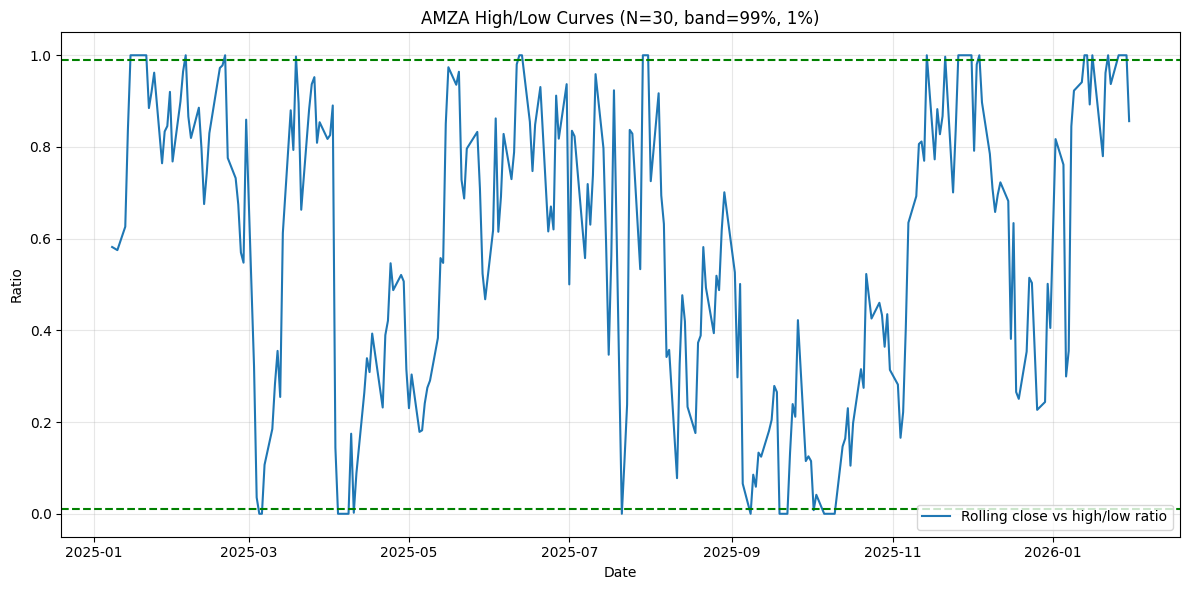

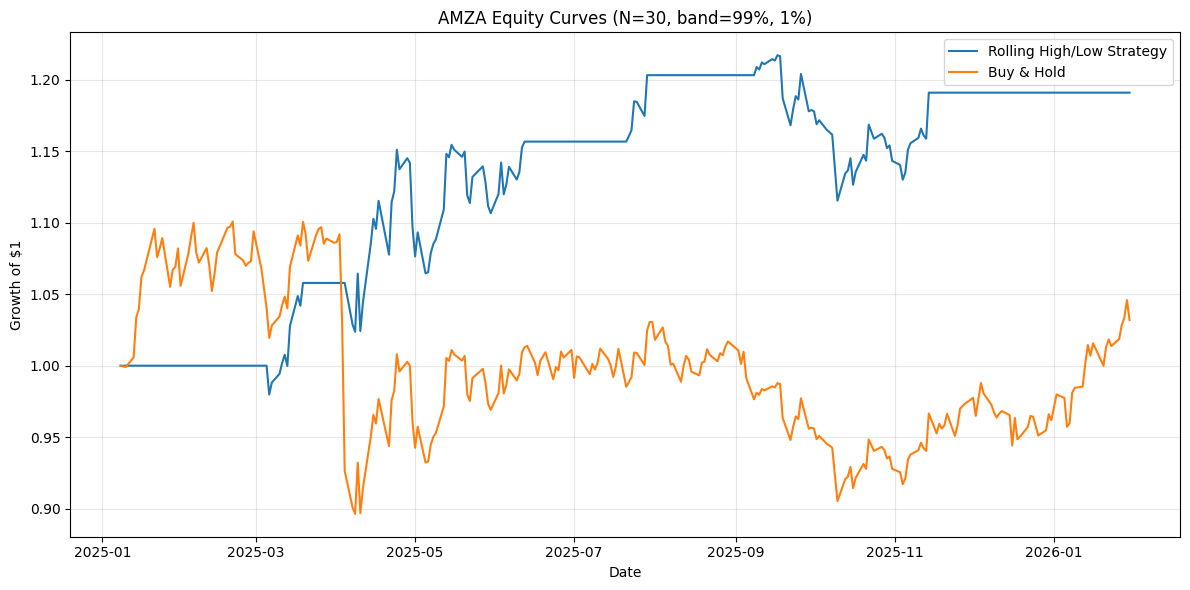

                      Strategy   BuyHold
Total Return          0.190923  0.031897
Ann. Return (approx)  0.177561  0.057956
Ann. Vol (approx)     0.155139  0.236223


                                                                     
Field                                                                
Ticker                                                            VTI
Name                                  Vanguard Total Stock Market ETF
Long Name           Vanguard Total Stock Market Index Fund ETF Shares
Price                                                          340.57
Dividend Yield (%)                                               1.12
Trailing EPS                                                     None
Forward EPS                                                      None
Trailing P/E                                                27.154198
Forward P/E                                                      None
Asset Type                                                      

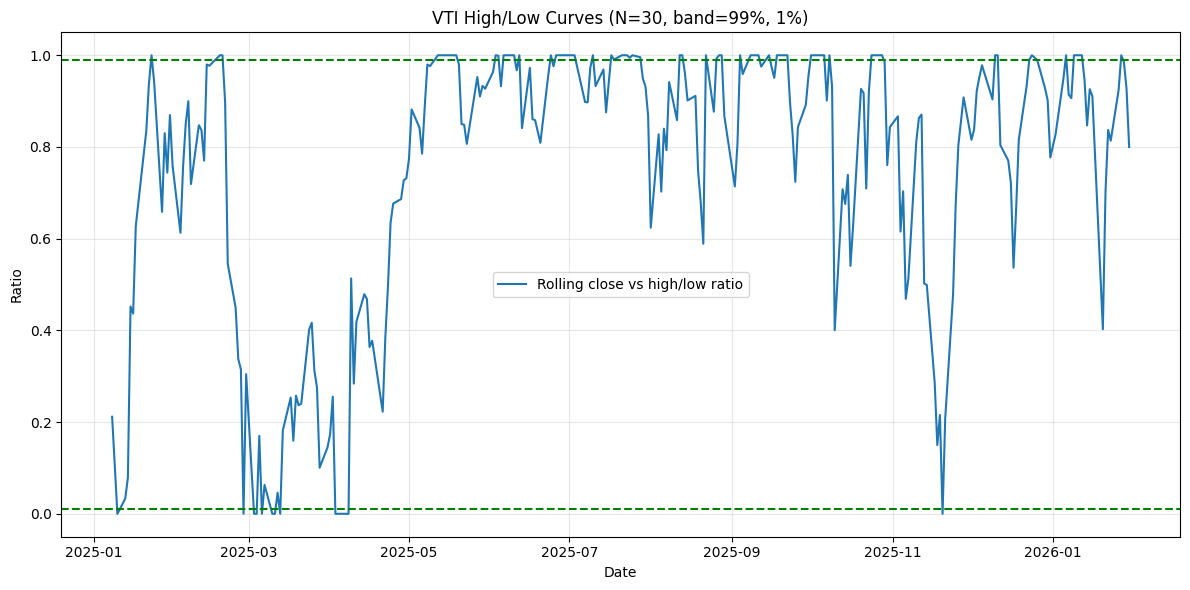

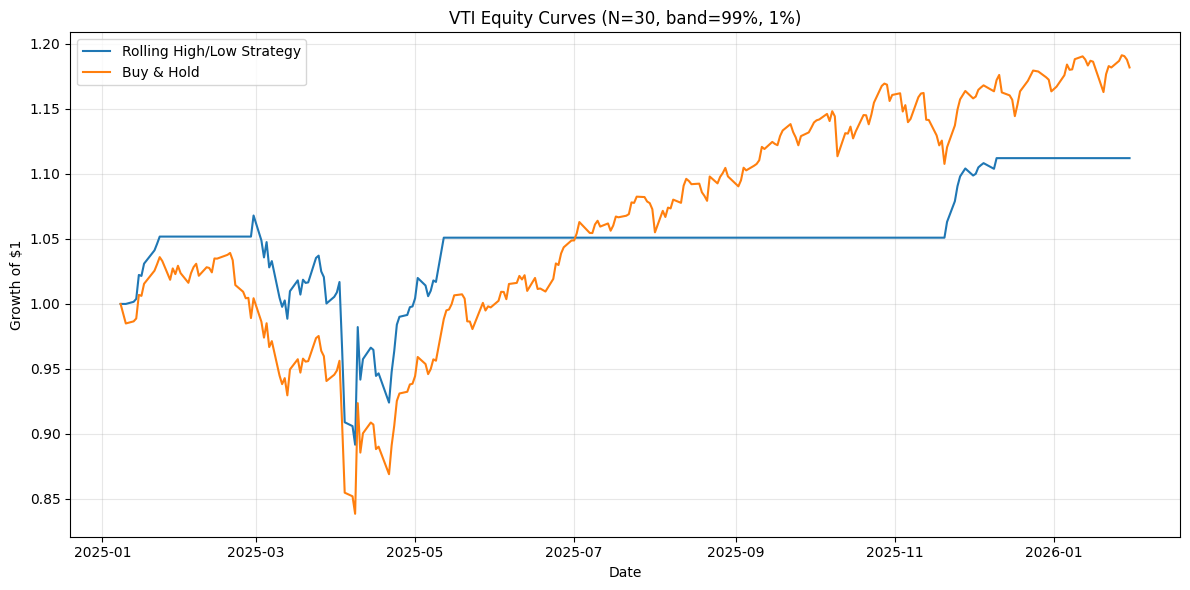

                      Strategy   BuyHold
Total Return          0.112120  0.181868
Ann. Return (approx)  0.113692  0.176085
Ann. Vol (approx)     0.162658  0.189567


                                                        
Field                                                   
Ticker                                               VTV
Name                                  Vanguard Value ETF
Long Name           Vanguard Value Index Fund ETF Shares
Price                                             199.75
Dividend Yield (%)                                  2.05
Trailing EPS                                        None
Forward EPS                                         None
Trailing P/E                                   21.145697
Forward P/E                                         None
Asset Type                                           ETF
from 2025-01-08 to 2026-01-31


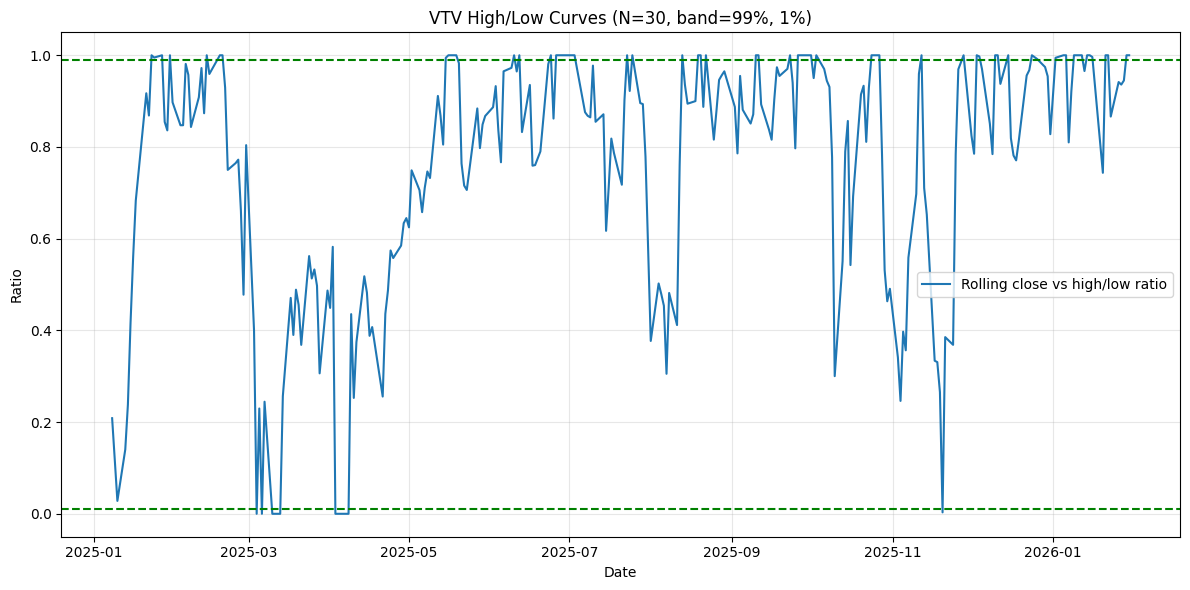

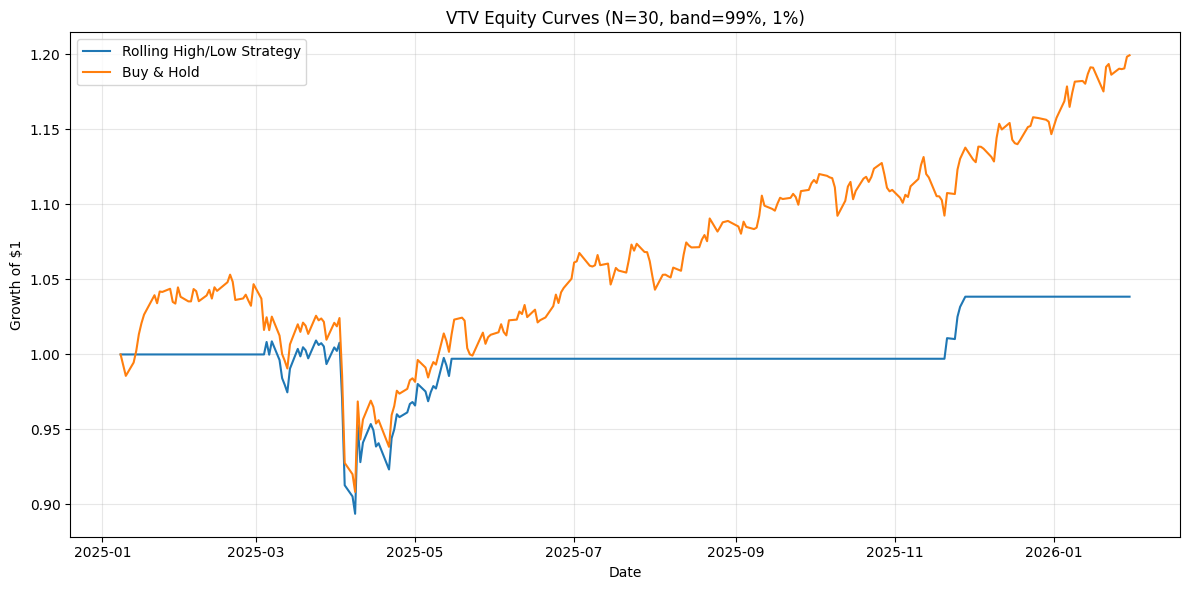

                      Strategy   BuyHold
Total Return          0.038505  0.199451
Ann. Return (approx)  0.042823  0.183438
Ann. Vol (approx)     0.118823  0.149178


                                                              
Field                                                         
Ticker                                                     VWO
Name                           Vanguard FTSE Emerging Markets 
Long Name           Vanguard Emerging Markets Stock Index Fund
Price                                                    56.47
Dividend Yield (%)                                        2.79
Trailing EPS                                              None
Forward EPS                                               None
Trailing P/E                                         17.180393
Forward P/E                                               None
Asset Type                                                 ETF
from 2025-01-08 to 2026-01-31


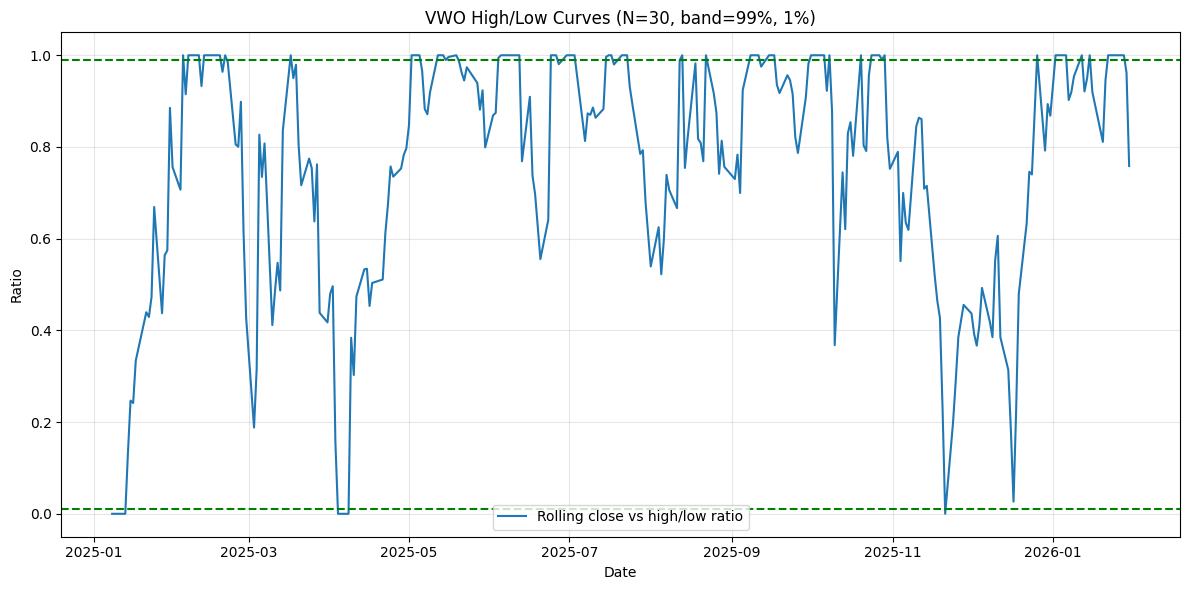

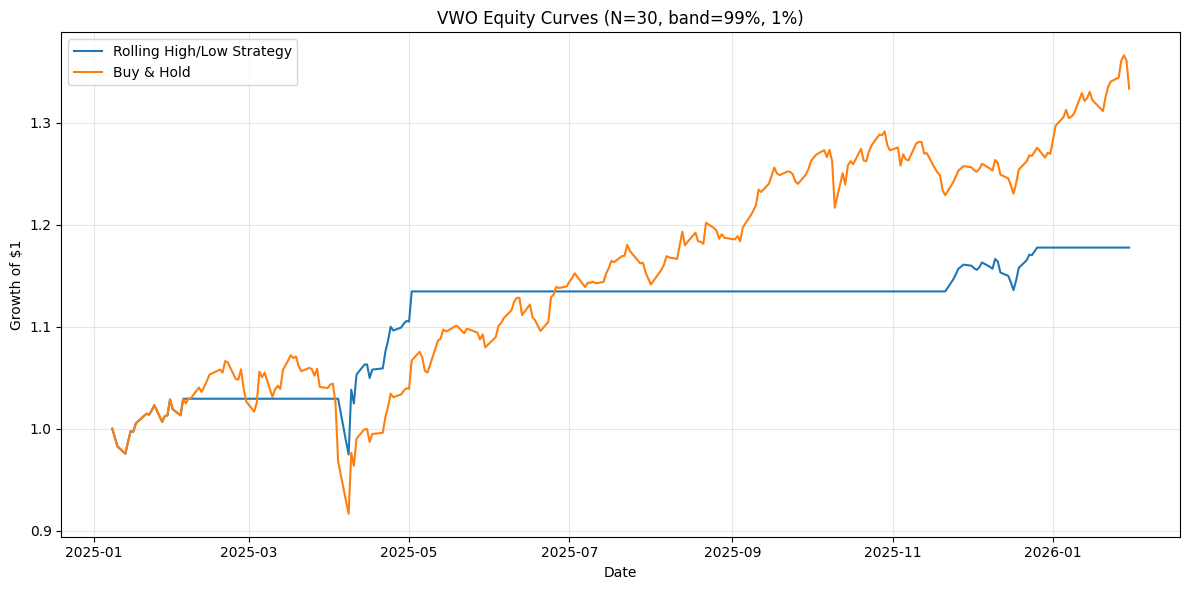

                      Strategy   BuyHold
Total Return          0.177703  0.333610
Ann. Return (approx)  0.160095  0.286523
Ann. Vol (approx)     0.101812  0.165510


                                                                     
Field                                                                
Ticker                                                            VEU
Name                                  Vanguard FTSE All World Ex US E
Long Name           Vanguard FTSE All-World ex-US Index Fund ETF S...
Price                                                           77.73
Dividend Yield (%)                                               3.09
Trailing EPS                                                     None
Forward EPS                                                      None
Trailing P/E                                                18.603668
Forward P/E                                                      None
Asset Type                                                      

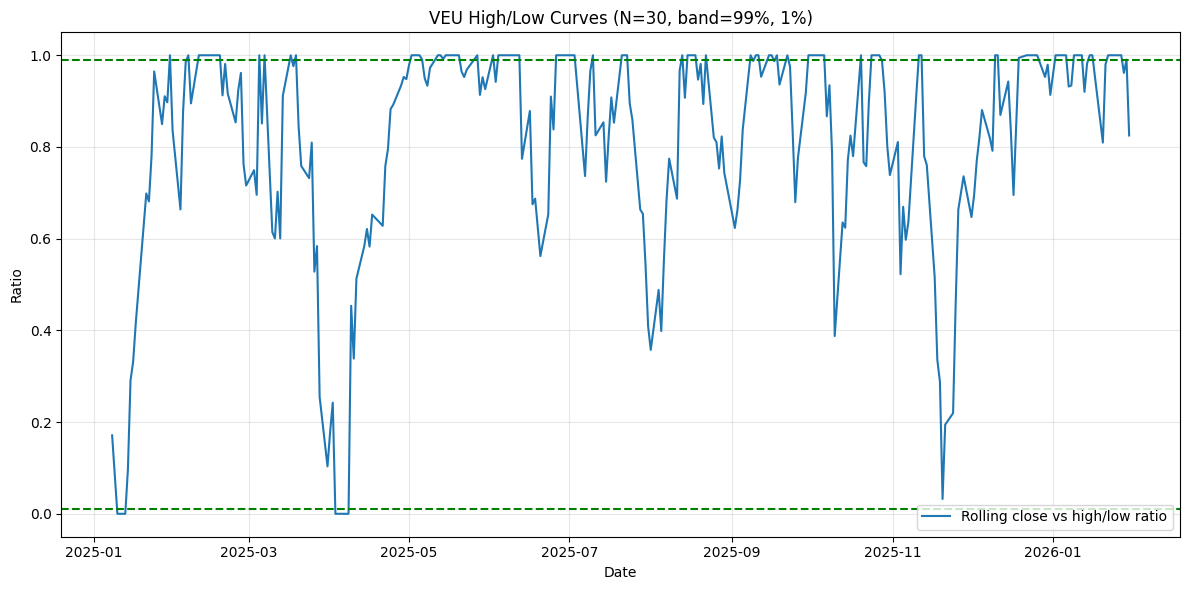

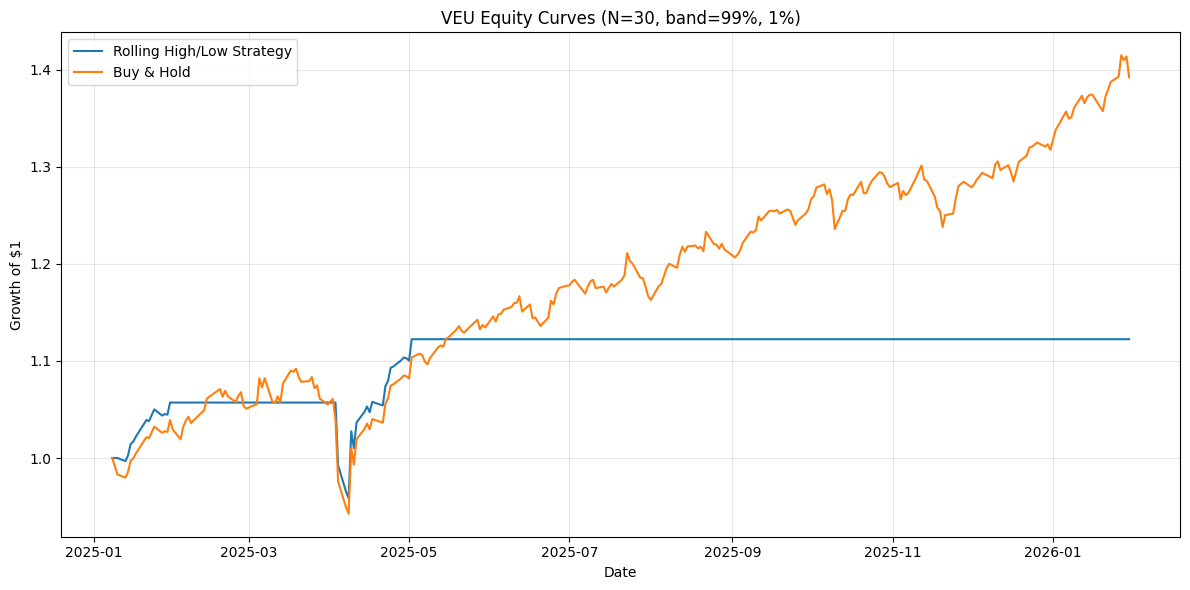

                      Strategy   BuyHold
Total Return          0.122429  0.392225
Ann. Return (approx)  0.115394  0.325690
Ann. Vol (approx)     0.109689  0.155448


                                                      
Field                                                 
Ticker                                            JEPI
Name                   JPMorgan Equity Premium Income 
Long Name           JPMorgan Equity Premium Income ETF
Price                                            58.56
Dividend Yield (%)                                8.25
Trailing EPS                                      None
Forward EPS                                       None
Trailing P/E                                 26.880213
Forward P/E                                       None
Asset Type                                         ETF
from 2025-01-08 to 2026-01-31


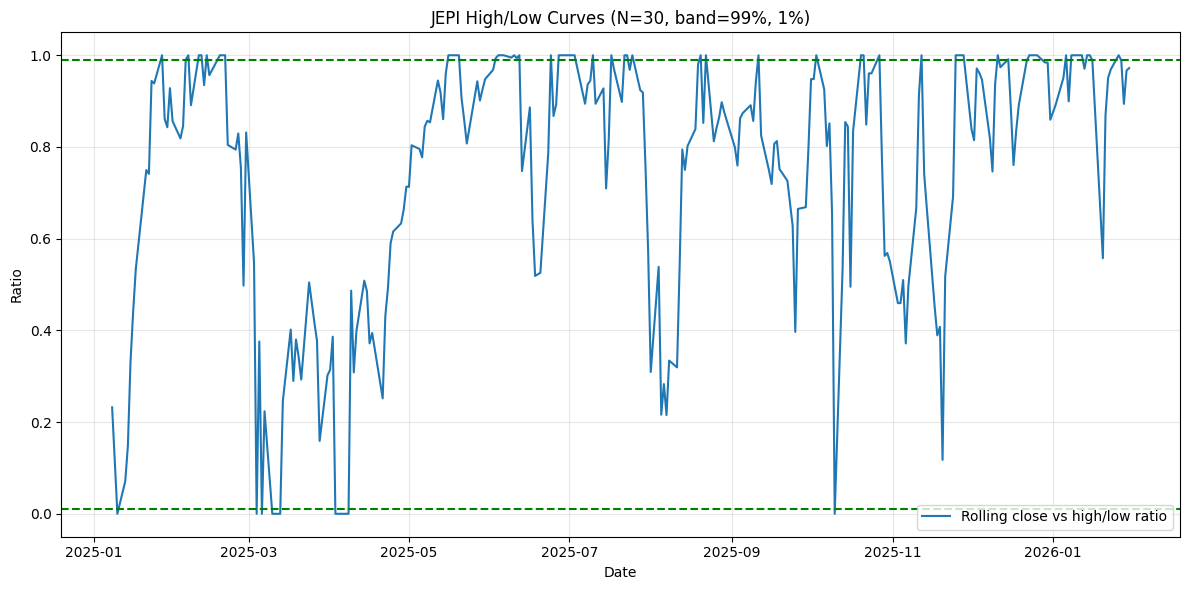

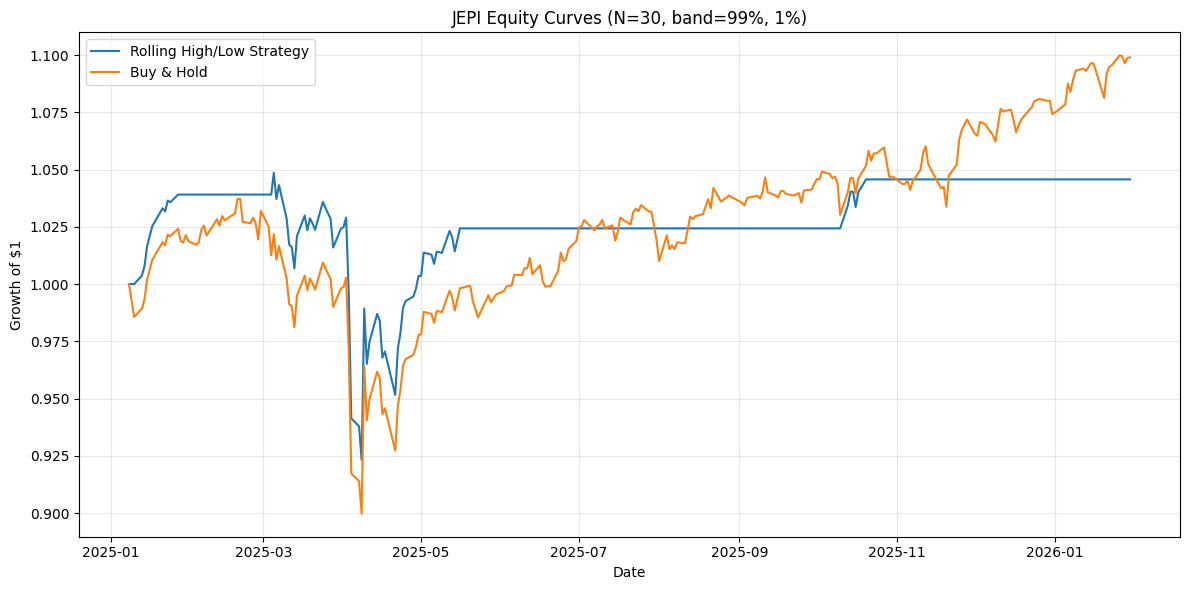

                      Strategy   BuyHold
Total Return          0.045715  0.098985
Ann. Return (approx)  0.048872  0.097869
Ann. Vol (approx)     0.114741  0.130391


                                                             
Field                                                        
Ticker                                                   JEPQ
Name                          JPMorgan Nasdaq Equity Premium 
Long Name           JPMorgan Nasdaq Equity Premium Income ETF
Price                                                   59.43
Dividend Yield (%)                                      10.54
Trailing EPS                                             None
Forward EPS                                              None
Trailing P/E                                        33.971416
Forward P/E                                              None
Asset Type                                                ETF
from 2025-01-08 to 2026-01-31


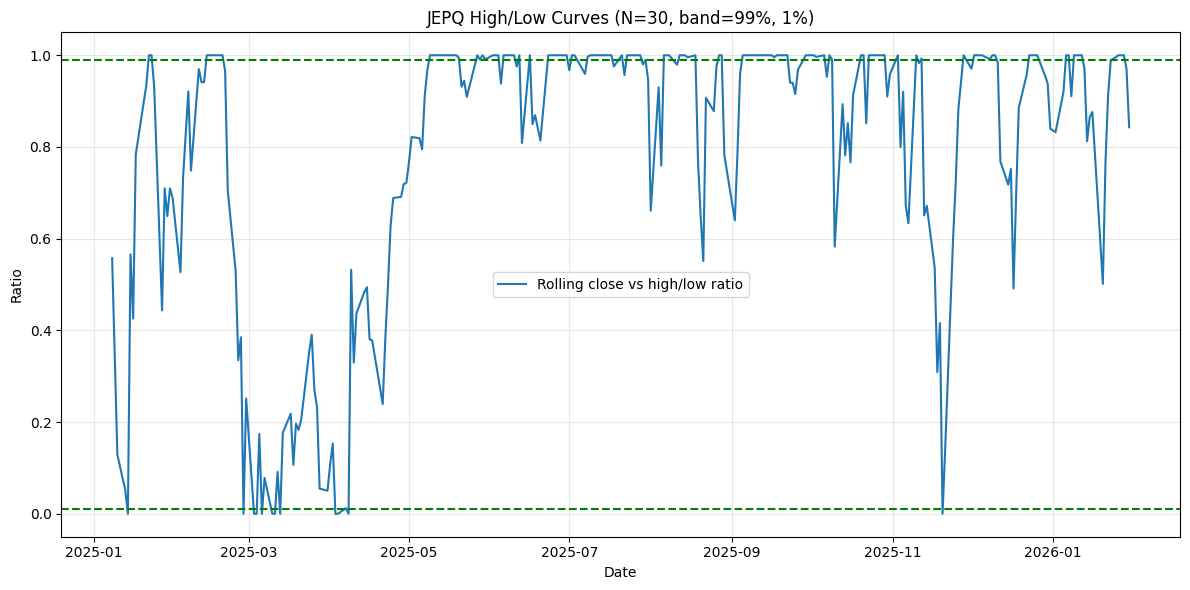

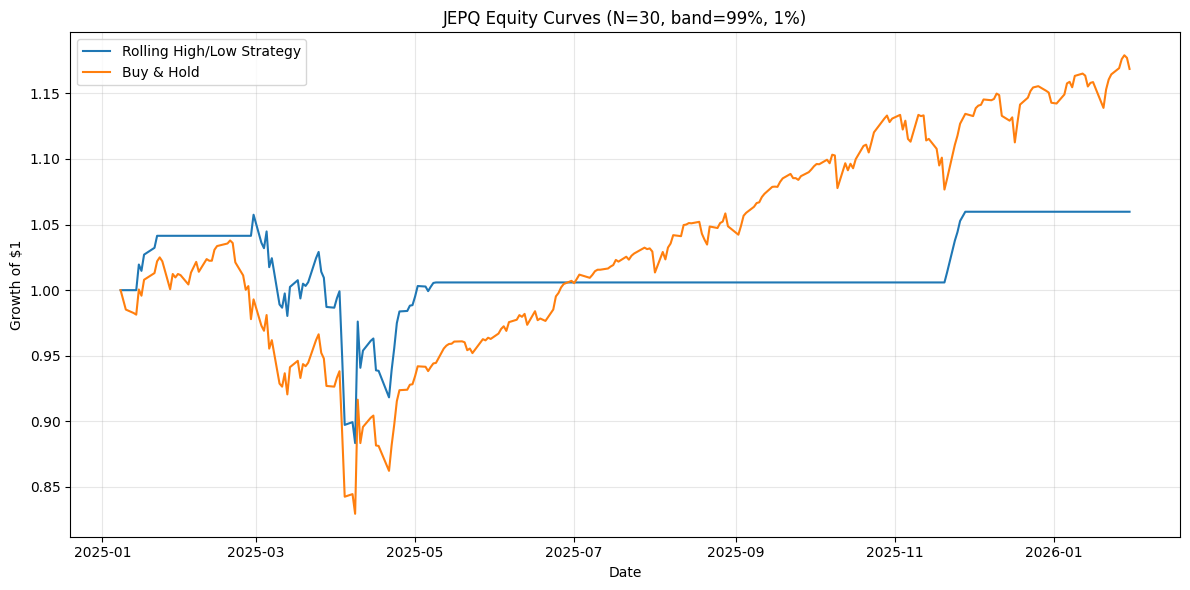

                      Strategy   BuyHold
Total Return          0.059765  0.168598
Ann. Return (approx)  0.067829  0.164895
Ann. Vol (approx)     0.161804  0.187089


                                                             
Field                                                        
Ticker                                                    VFH
Name                                  Vanguard Financials ETF
Long Name           Vanguard Financials Index Fund ETF Shares
Price                                                  130.89
Dividend Yield (%)                                       1.56
Trailing EPS                                             None
Forward EPS                                              None
Trailing P/E                                        17.721361
Forward P/E                                              None
Asset Type                                                ETF
from 2025-01-08 to 2026-01-31


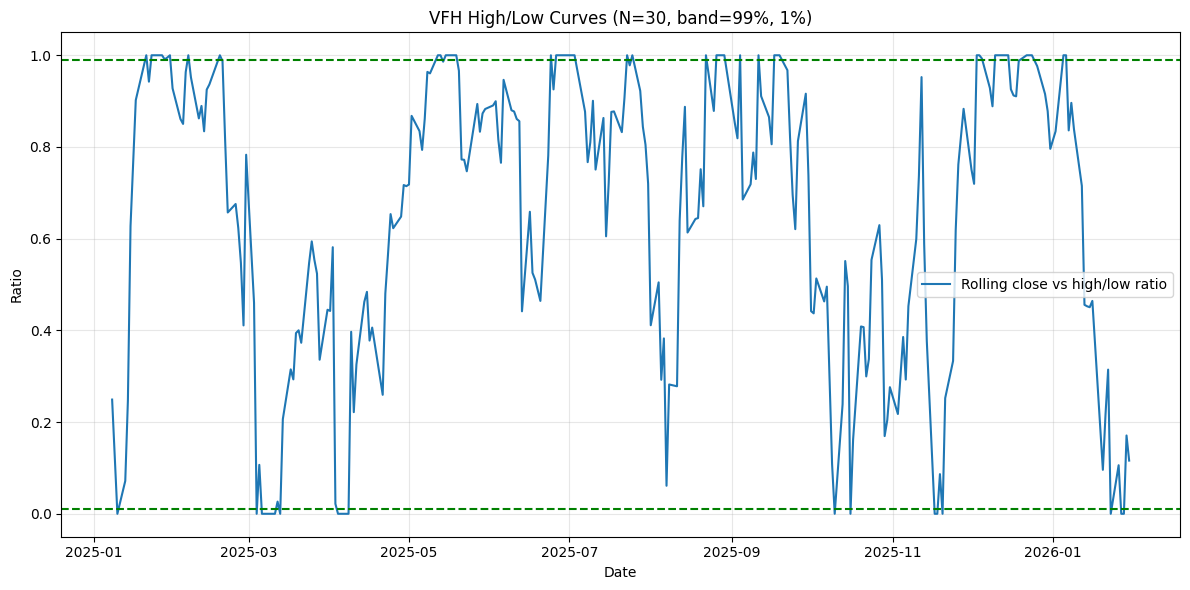

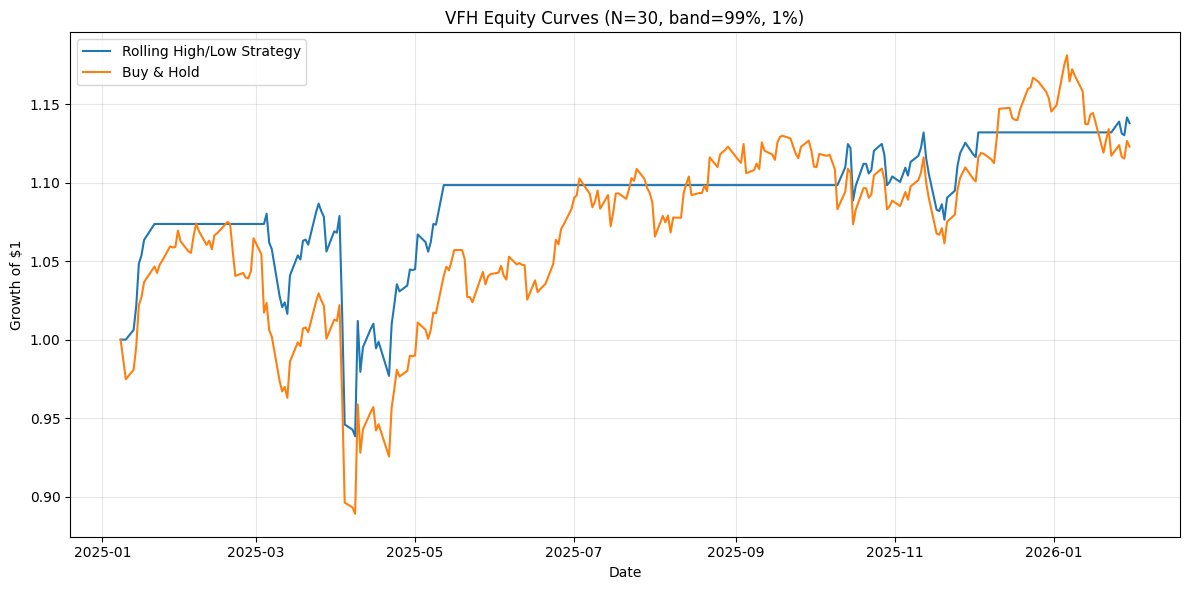

                      Strategy   BuyHold
Total Return          0.137966  0.123022
Ann. Return (approx)  0.135564  0.129536
Ann. Vol (approx)     0.161892  0.198000




In [4]:
for ticker in ["AMZA", "VTI", "VTV", "VWO", "VEU", "JEPI", "JEPQ", "VFH"]:
  rolling_high_low_strategy(ticker,N=30,start_date="2025-01-08")

In [5]:
def adj_close(ticker, start_date='2024-01-01'):
  end_date = date.today().strftime('%Y-%m-%d')
  data, stock = get_fundamentals(ticker)
  print(f"{ticker}: {stock.info['longName']} from {start_date} to {end_date}")
  df = stock.history(start=start_date, end=end_date, auto_adjust=False)
  returns = df[['Close', 'Adj Close']].pct_change().fillna(0.0)
  return_1y = returns.mean() * 252
  data.loc['Annual Return'] = return_1y["Close"] * 100
  data.loc['Annual Return Adj'] = return_1y["Adj Close" ] * 100
  stdev_1y = returns.std() * np.sqrt(252)
  data.loc['Annual Volatility'] = stdev_1y["Close"] * 100
  sharpe = (return_1y - 0.03) / stdev_1y 
  data.loc['Sharpe Ratio'] = sharpe["Close"]
  data.loc['Sharpe Ratio Adj'] = sharpe["Adj Close"]
  print(data)
  df['Adj Close'] += (df['Close'].iloc[0] -  df['Adj Close'].iloc[0])
  end_date = df.index.max()
  start_date = end_date - pd.DateOffset(years=1)
  #div_1y = df.loc[start_date:][df['Dividends'] > 0]['Dividends'].count()
  div_1y = df.loc[
    (df.index >= start_date) & (df["Dividends"] > 0),
    "Dividends"].count()
  div_percentage = df['Dividends'] * 100 * div_1y / df['Close']

  div_percentage = div_percentage.apply(lambda x: '{:.2f}%'.format(x) if x > 0 else '')

  fig, ax1 = plt.subplots(figsize=(12, 6))
  ax1.plot(df.index, df[['Close', 'Adj Close']], label=df[['Close', 'Adj Close']].columns)
  ax1.set_title(f"{ticker} Adjusted Close and Dividends")
  ax1.set_xlabel("Date")
  ax1.set_ylabel("Close")
  ax1.legend()

  ax2 = ax1.twinx()
  bar = ax2.bar(df.index, df['Dividends'], color='green', alpha=0.3, label='Dividends', width=5)
  ax2.bar_label(bar, labels = div_percentage, fmt='{:.2f}%', label_type='edge')
  ax2.set_ylabel('Dividend Amount ($)', color='green')
  ax2.tick_params(axis='y', labelcolor='green')
  plt.tight_layout()
  plt.grid(True, alpha=0.3)
  plt.show()


BKLN: Invesco Senior Loan ETF from 2025-01-01 to 2026-01-31
                                           
Field                                      
Ticker                                 BKLN
Name                Invesco Senior Loan ETF
Long Name           Invesco Senior Loan ETF
Price                                 20.74
Dividend Yield (%)                     6.96
Trailing EPS                           None
Forward EPS                            None
Trailing P/E                           None
Forward P/E                            None
Asset Type                              ETF
Annual Return                     -1.390877
Annual Return Adj                  5.598865
Annual Volatility                  4.074925
Sharpe Ratio                      -1.077536
Sharpe Ratio Adj                   0.711983


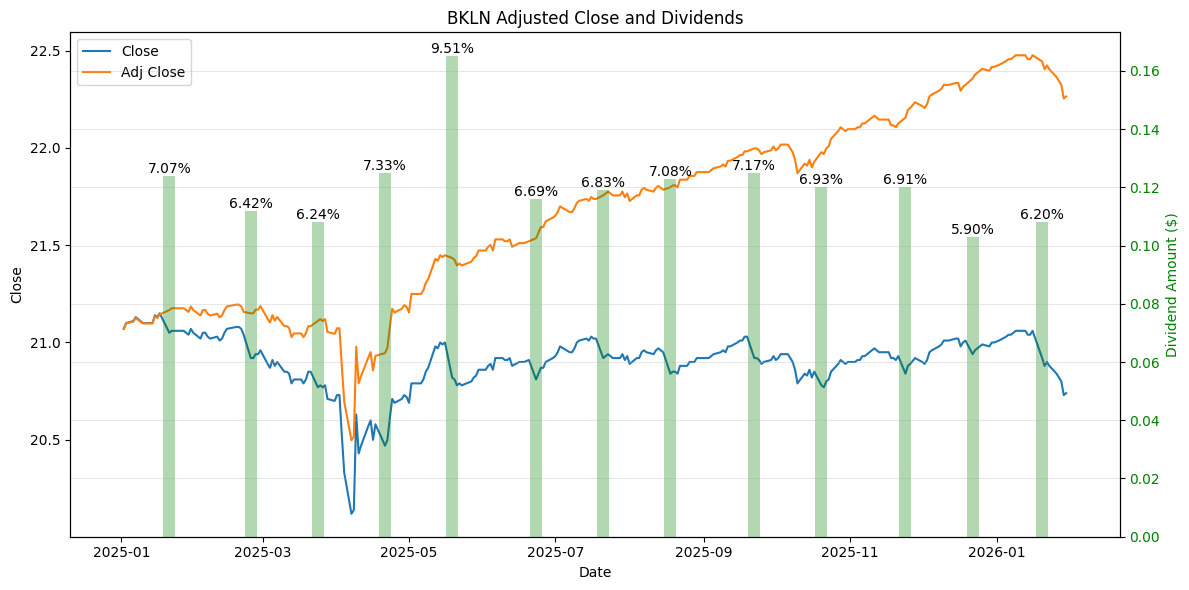

CLOA: iShares AAA CLO Active ETF from 2025-01-01 to 2026-01-31
                                              
Field                                         
Ticker                                    CLOA
Name                iShares AAA CLO Active ETF
Long Name           iShares AAA CLO Active ETF
Price                                   52.045
Dividend Yield (%)                        5.35
Trailing EPS                              None
Forward EPS                               None
Trailing P/E                              None
Forward P/E                               None
Asset Type                                 ETF
Annual Return                         0.515792
Annual Return Adj                     5.497009
Annual Volatility                     2.067137
Sharpe Ratio                         -1.201763
Sharpe Ratio Adj                      1.527218


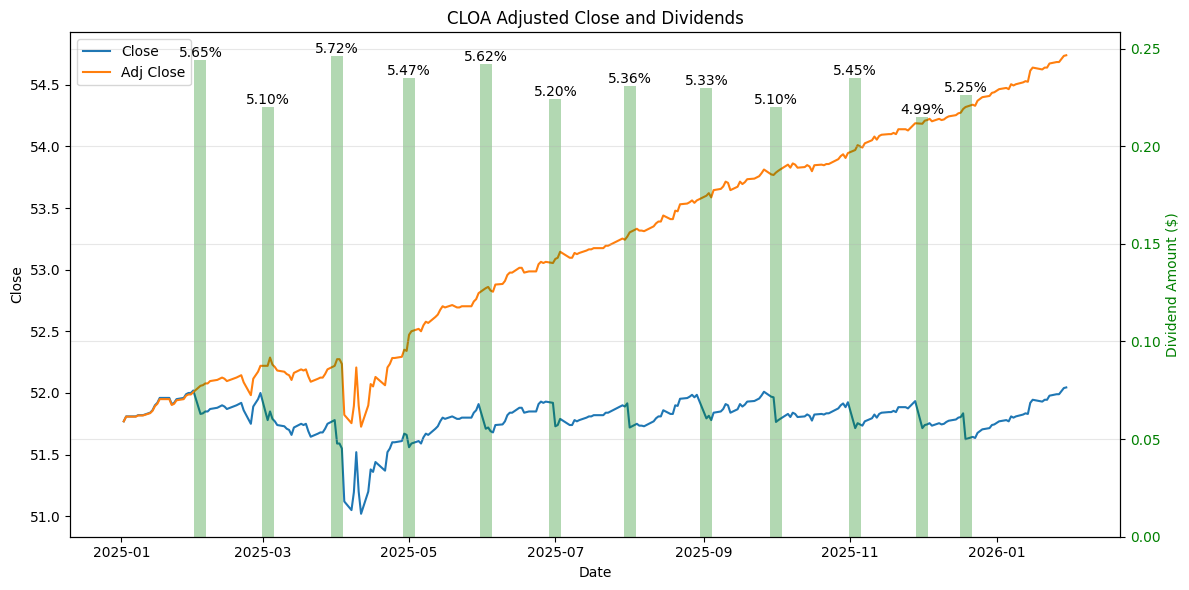

PFRL: PGIM Floating Rate Income ETF from 2025-01-01 to 2026-01-31
                                                 
Field                                            
Ticker                                       PFRL
Name                PGIM Floating Rate Income ETF
Long Name           PGIM Floating Rate Income ETF
Price                                     49.6631
Dividend Yield (%)                           7.36
Trailing EPS                                 None
Forward EPS                                  None
Trailing P/E                                 None
Forward P/E                                  None
Asset Type                                    ETF
Annual Return                           -0.979485
Annual Return Adj                        5.827265
Annual Volatility                        8.445106
Sharpe Ratio                            -0.471218
Sharpe Ratio Adj                         0.343494


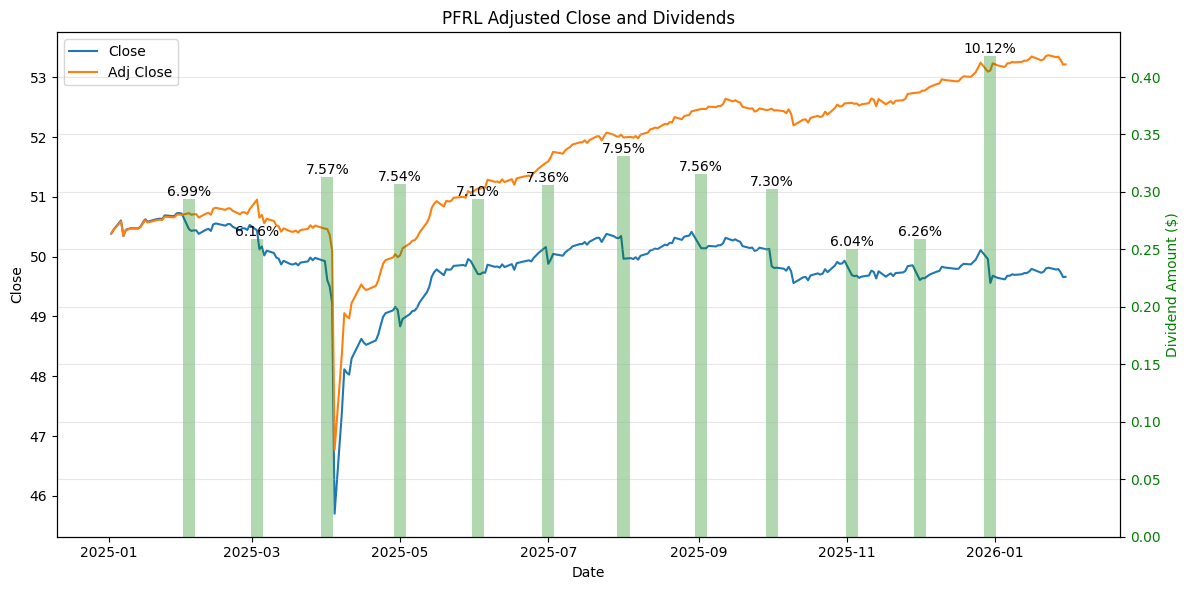

VCLT: Vanguard Long-Term Corporate Bond Index Fund ETF Shares from 2025-01-01 to 2026-01-31
                                                                     
Field                                                                
Ticker                                                           VCLT
Name                                  Vanguard Long-Term Corporate Bo
Long Name           Vanguard Long-Term Corporate Bond Index Fund E...
Price                                                           76.21
Dividend Yield (%)                                               5.51
Trailing EPS                                                     None
Forward EPS                                                      None
Trailing P/E                                                     None
Forward P/E                                                      None
Asset Type                                                        ETF
Annual Return                                                 2.2637

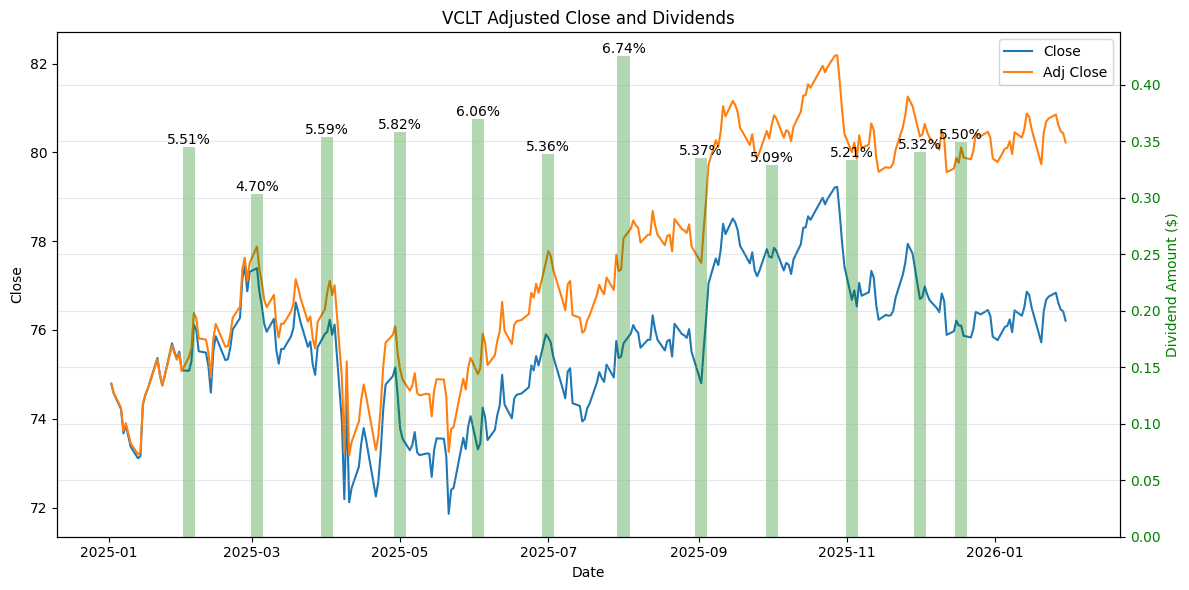

VTC: Vanguard Total Corporate Bond ETF ETF Shares from 2025-01-01 to 2026-01-31
                                                                
Field                                                           
Ticker                                                       VTC
Name                             Vanguard Total Corporate Bond E
Long Name           Vanguard Total Corporate Bond ETF ETF Shares
Price                                                    77.9687
Dividend Yield (%)                                          4.77
Trailing EPS                                                None
Forward EPS                                                 None
Trailing P/E                                                None
Forward P/E                                                 None
Asset Type                                                   ETF
Annual Return                                            2.88041
Annual Return Adj                                       7.349761
Annual Vol

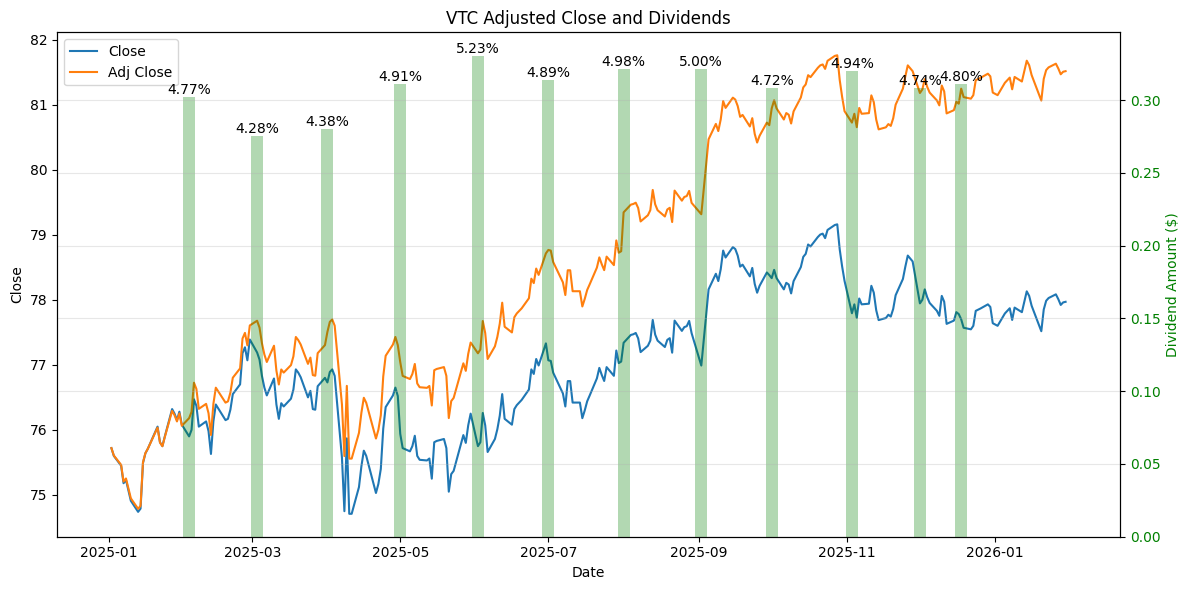

VUSB: Vanguard Ultra-Short Bond ETF from 2025-01-01 to 2026-01-31
                                                 
Field                                            
Ticker                                       VUSB
Name                Vanguard Ultra-Short Bond ETF
Long Name           Vanguard Ultra-Short Bond ETF
Price                                       50.03
Dividend Yield (%)                           4.63
Trailing EPS                                 None
Forward EPS                                  None
Trailing P/E                                 None
Forward P/E                                  None
Asset Type                                    ETF
Annual Return                            0.778218
Annual Return Adj                        5.093505
Annual Volatility                        1.428292
Sharpe Ratio                            -1.555551
Sharpe Ratio Adj                         3.012602


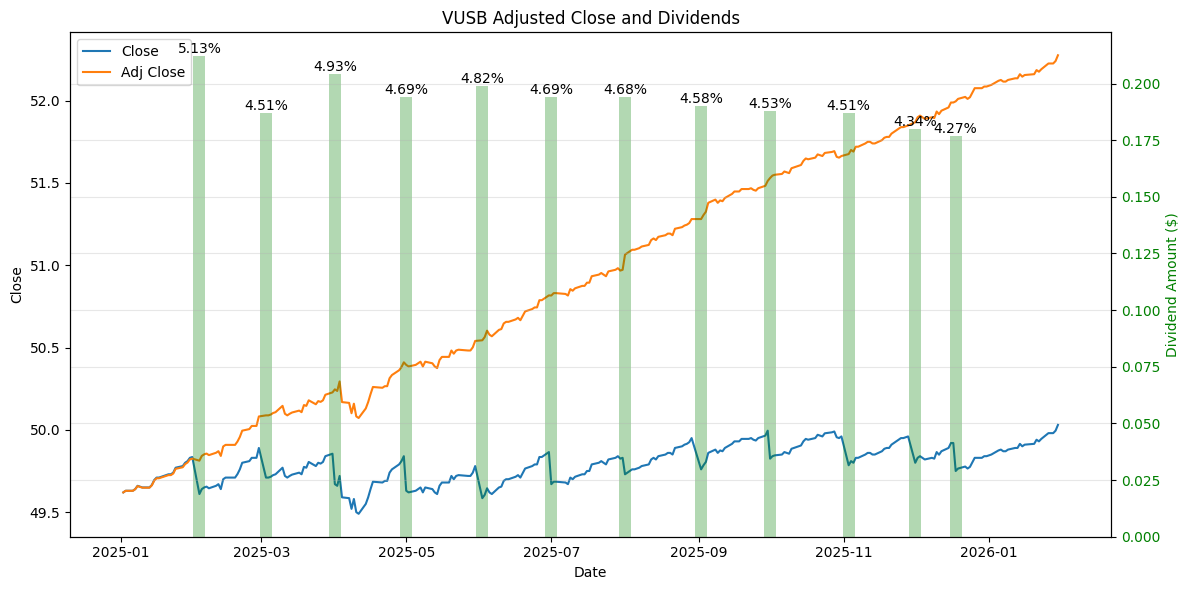

VWOB: Vanguard Emerging Markets Government Bond Index Fund from 2025-01-01 to 2026-01-31
                                                                     
Field                                                                
Ticker                                                           VWOB
Name                                  Vanguard Emerging Markets Gover
Long Name           Vanguard Emerging Markets Government Bond Inde...
Price                                                           67.66
Dividend Yield (%)                                               5.93
Trailing EPS                                                     None
Forward EPS                                                      None
Trailing P/E                                                     None
Forward P/E                                                      None
Asset Type                                                        ETF
Annual Return                                                6.382124
A

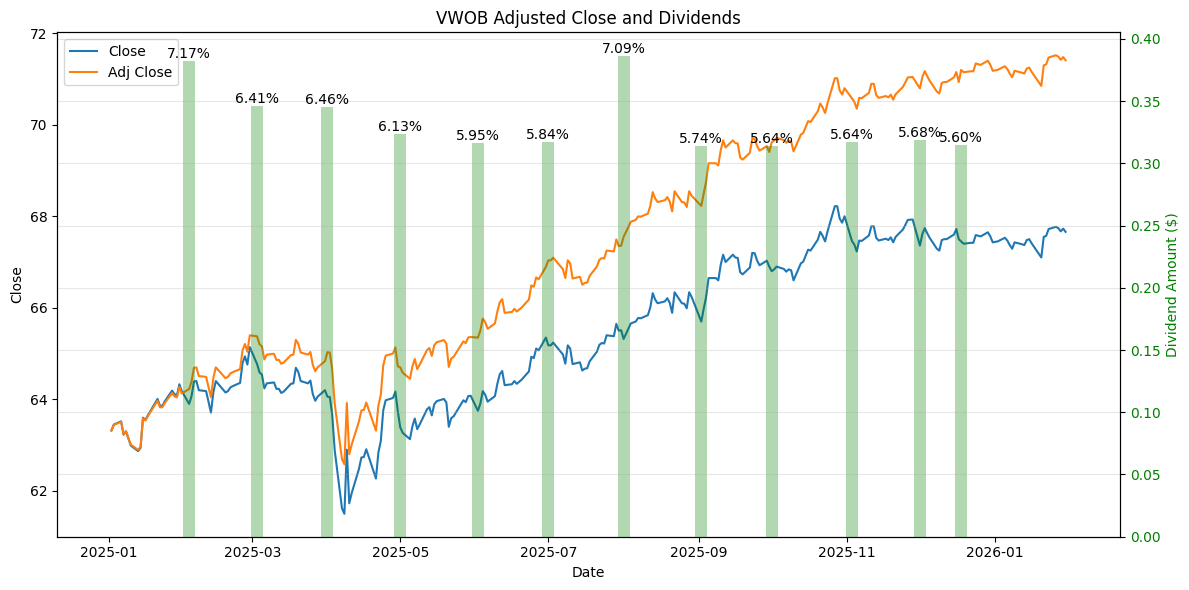

AMZA: InfraCap MLP ETF from 2025-01-01 to 2026-01-31
                                    
Field                               
Ticker                          AMZA
Name                InfraCap MLP ETF
Long Name           InfraCap MLP ETF
Price                          42.04
Dividend Yield (%)               8.8
Trailing EPS                    None
Forward EPS                     None
Trailing P/E               15.425261
Forward P/E                     None
Asset Type                       ETF
Annual Return              -0.424229
Annual Return Adj           7.863295
Annual Volatility          23.731306
Sharpe Ratio               -0.144292
Sharpe Ratio Adj            0.206944


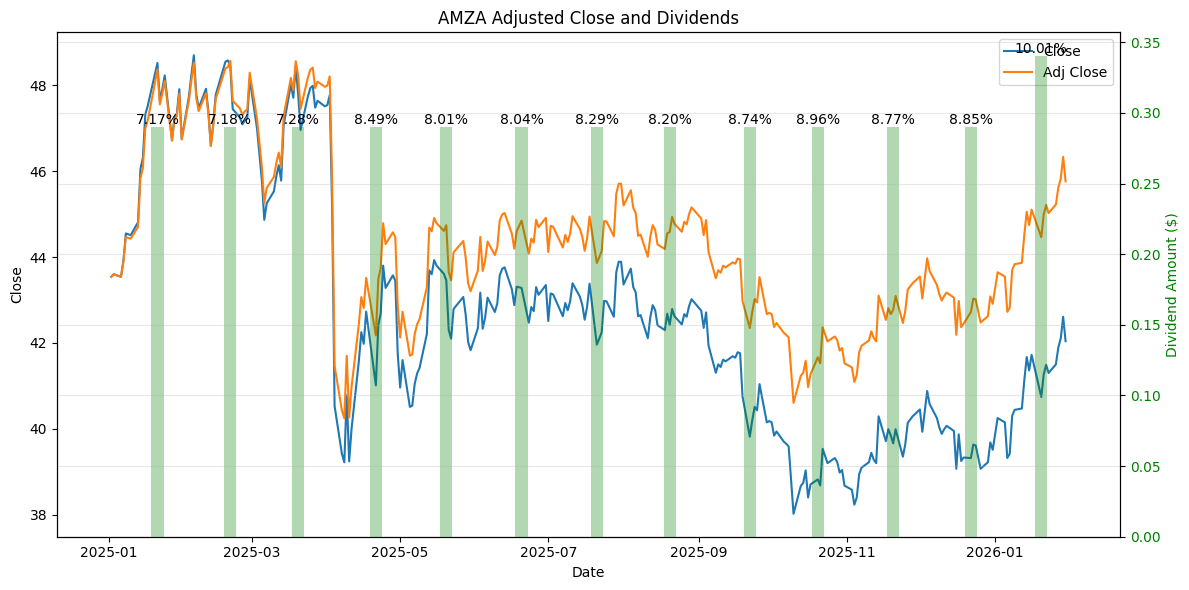

VYM: Vanguard High Dividend Yield Index Fund ETF Shares from 2025-01-01 to 2026-01-31
                                                                     
Field                                                                
Ticker                                                            VYM
Name                                  Vanguard High Dividend Yield ET
Long Name           Vanguard High Dividend Yield Index Fund ETF Sh...
Price                                                          149.96
Dividend Yield (%)                                               2.44
Trailing EPS                                                     None
Forward EPS                                                      None
Trailing P/E                                                20.903074
Forward P/E                                                      None
Asset Type                                                        ETF
Annual Return                                               16.255568
Annu

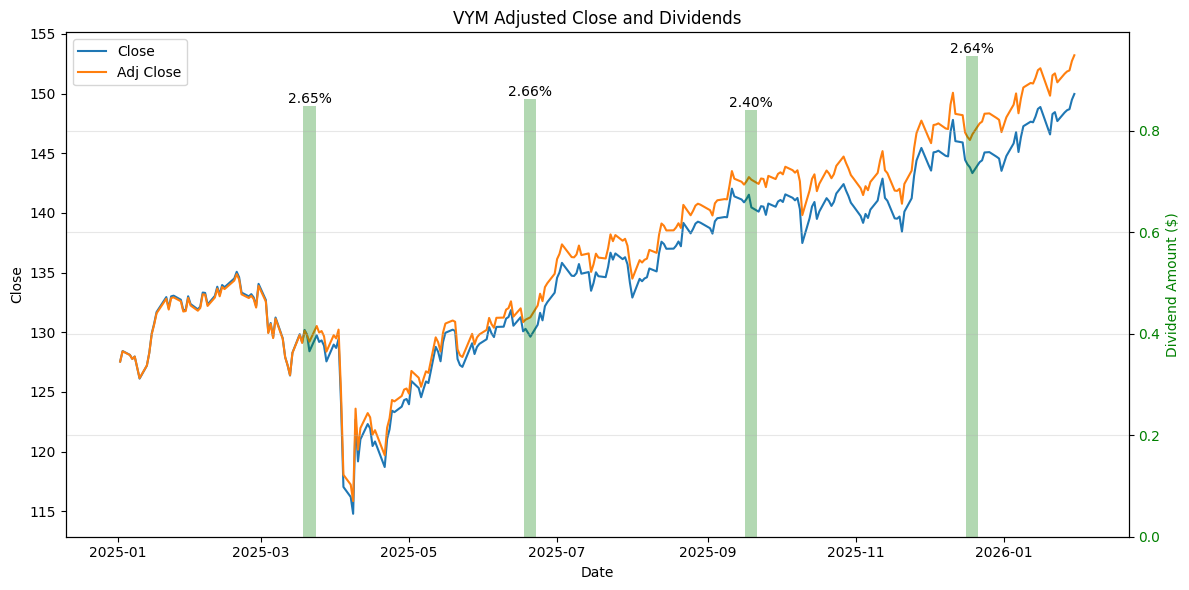

VYMI: Vanguard International High Dividend Yield Index Fund ETF Shares from 2025-01-01 to 2026-01-31
                                                                     
Field                                                                
Ticker                                                           VYMI
Name                                  Vanguard International High Div
Long Name           Vanguard International High Dividend Yield Ind...
Price                                                           95.14
Dividend Yield (%)                                               3.69
Trailing EPS                                                     None
Forward EPS                                                      None
Trailing P/E                                                14.522753
Forward P/E                                                      None
Asset Type                                                        ETF
Annual Return                                              

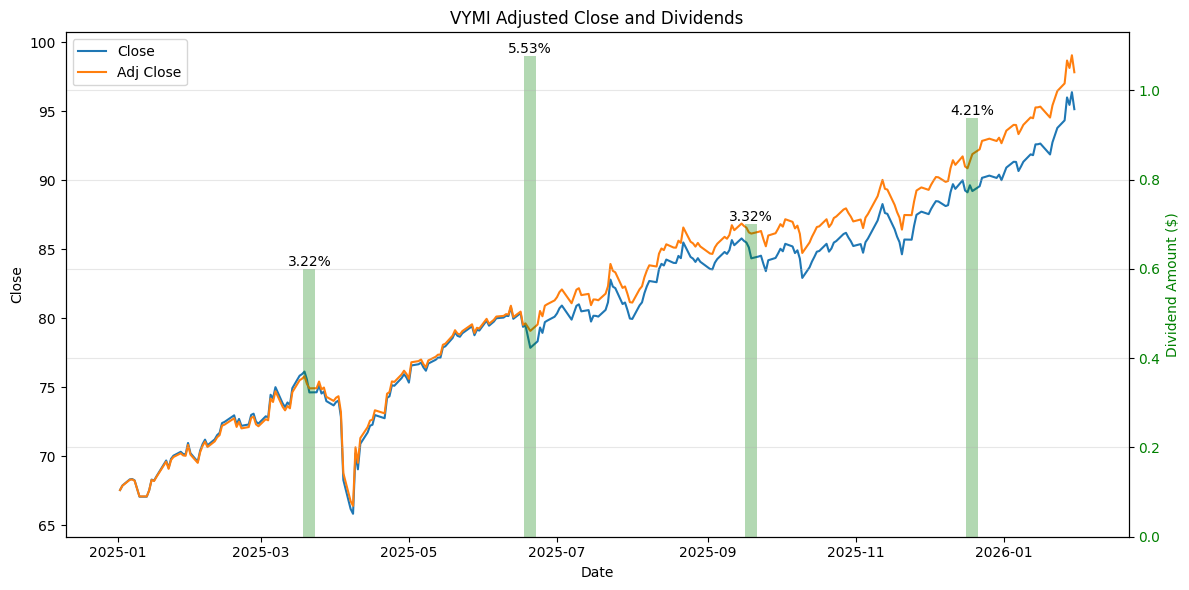

JEPI: JPMorgan Equity Premium Income ETF from 2025-01-01 to 2026-01-31
                                                      
Field                                                 
Ticker                                            JEPI
Name                   JPMorgan Equity Premium Income 
Long Name           JPMorgan Equity Premium Income ETF
Price                                            58.56
Dividend Yield (%)                                8.25
Trailing EPS                                      None
Forward EPS                                       None
Trailing P/E                                 26.880213
Forward P/E                                       None
Asset Type                                         ETF
Annual Return                                 2.598932
Annual Return Adj                            10.294084
Annual Volatility                            13.299388
Sharpe Ratio                                 -0.030157
Sharpe Ratio Adj                               0.

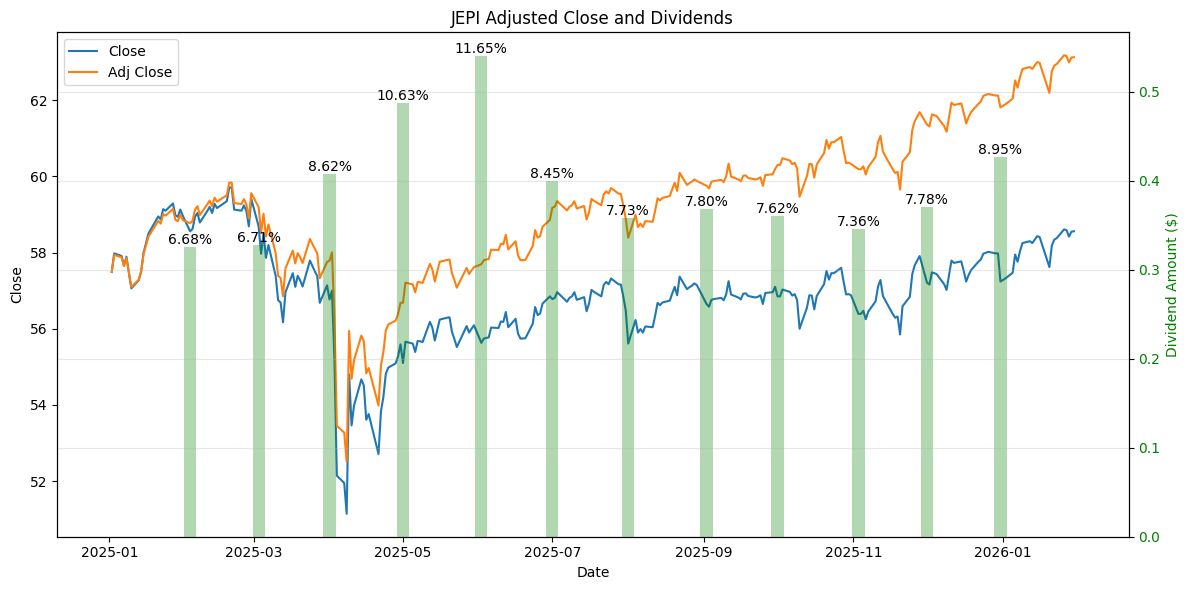

JEPQ: JPMorgan Nasdaq Equity Premium Income ETF from 2025-01-01 to 2026-01-31
                                                             
Field                                                        
Ticker                                                   JEPQ
Name                          JPMorgan Nasdaq Equity Premium 
Long Name           JPMorgan Nasdaq Equity Premium Income ETF
Price                                                   59.43
Dividend Yield (%)                                      10.54
Trailing EPS                                             None
Forward EPS                                              None
Trailing P/E                                        33.971416
Forward P/E                                              None
Asset Type                                                ETF
Annual Return                                        6.882217
Annual Return Adj                                   17.159594
Annual Volatility                                   19

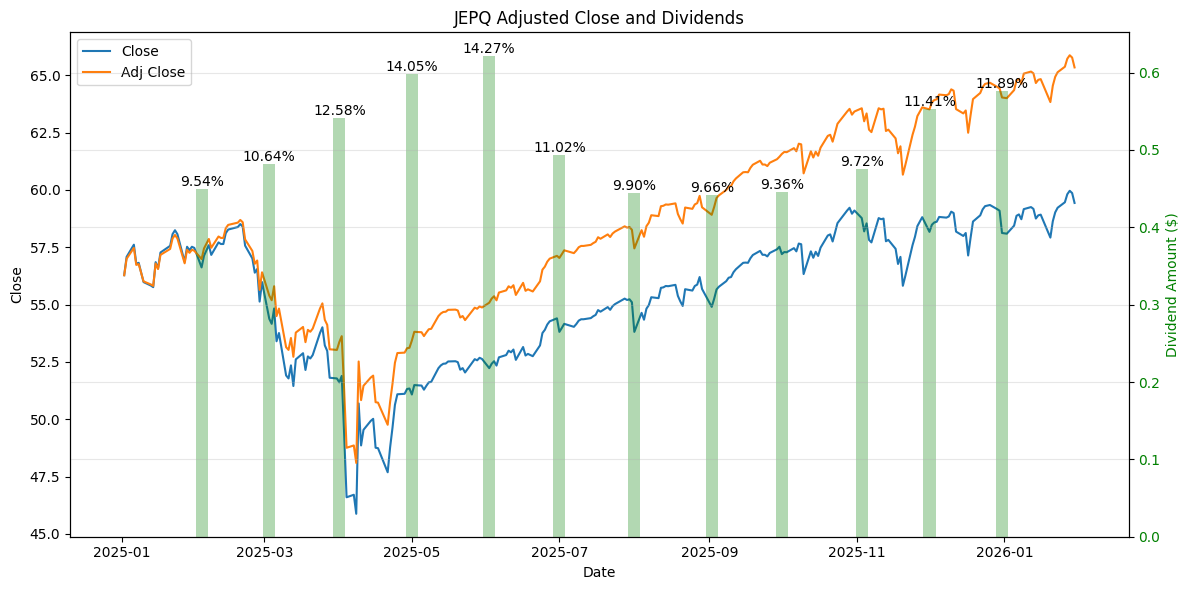

VOO: Vanguard S&P 500 ETF from 2025-01-01 to 2026-01-31
                                        
Field                                   
Ticker                               VOO
Name                Vanguard S&P 500 ETF
Long Name           Vanguard S&P 500 ETF
Price                             636.22
Dividend Yield (%)                  1.13
Trailing EPS                        None
Forward EPS                         None
Trailing P/E                   28.047958
Forward P/E                         None
Asset Type                           ETF
Annual Return                  17.358208
Annual Return Adj              18.500455
Annual Volatility              18.034221
Sharpe Ratio                    0.796165
Sharpe Ratio Adj                0.859394


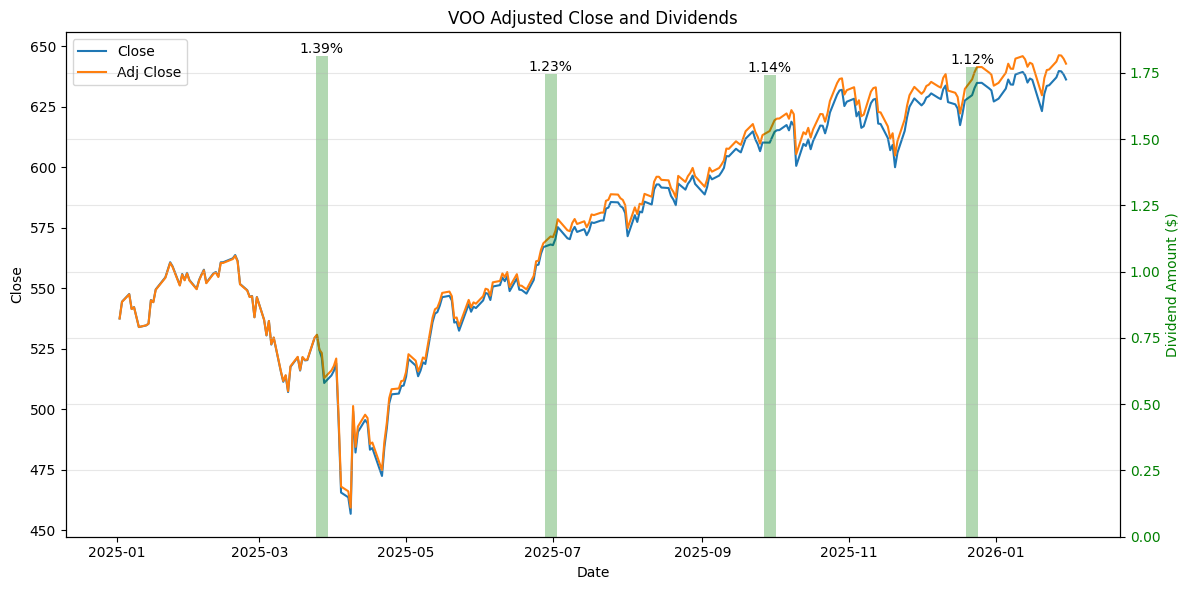

JAAA: Janus Henderson AAA CLO ETF from 2025-01-01 to 2026-01-31
                                               
Field                                          
Ticker                                     JAAA
Name                Janus Henderson AAA CLO ETF
Long Name           Janus Henderson AAA CLO ETF
Price                                     50.67
Dividend Yield (%)                          5.3
Trailing EPS                               None
Forward EPS                                None
Trailing P/E                               None
Forward P/E                                None
Asset Type                                  ETF
Annual Return                         -0.123383
Annual Return Adj                      4.806863
Annual Volatility                      2.186224
Sharpe Ratio                          -1.428665
Sharpe Ratio Adj                       1.033021


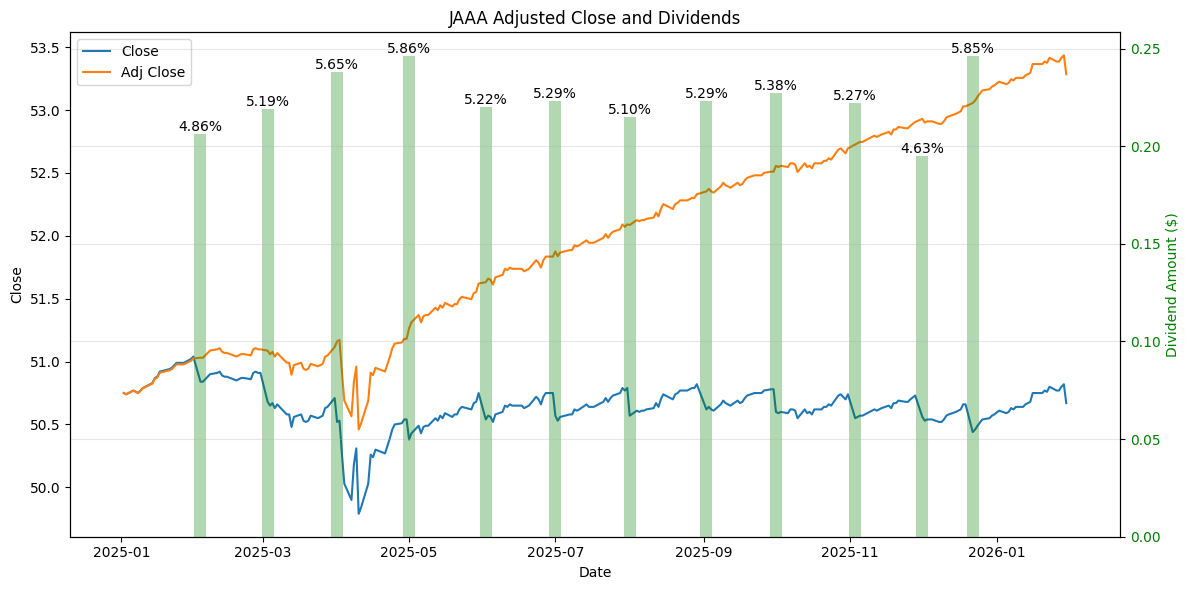

JBBB: Janus Henderson B-BBB CLO ETF from 2025-01-01 to 2026-01-31
                                                 
Field                                            
Ticker                                       JBBB
Name                Janus Henderson B-BBB CLO ETF
Long Name           Janus Henderson B-BBB CLO ETF
Price                                       47.84
Dividend Yield (%)                            7.4
Trailing EPS                                 None
Forward EPS                                  None
Trailing P/E                                 None
Forward P/E                                  None
Asset Type                                    ETF
Annual Return                            -2.73899
Annual Return Adj                        4.074858
Annual Volatility                        4.972727
Sharpe Ratio                            -1.154093
Sharpe Ratio Adj                         0.234106


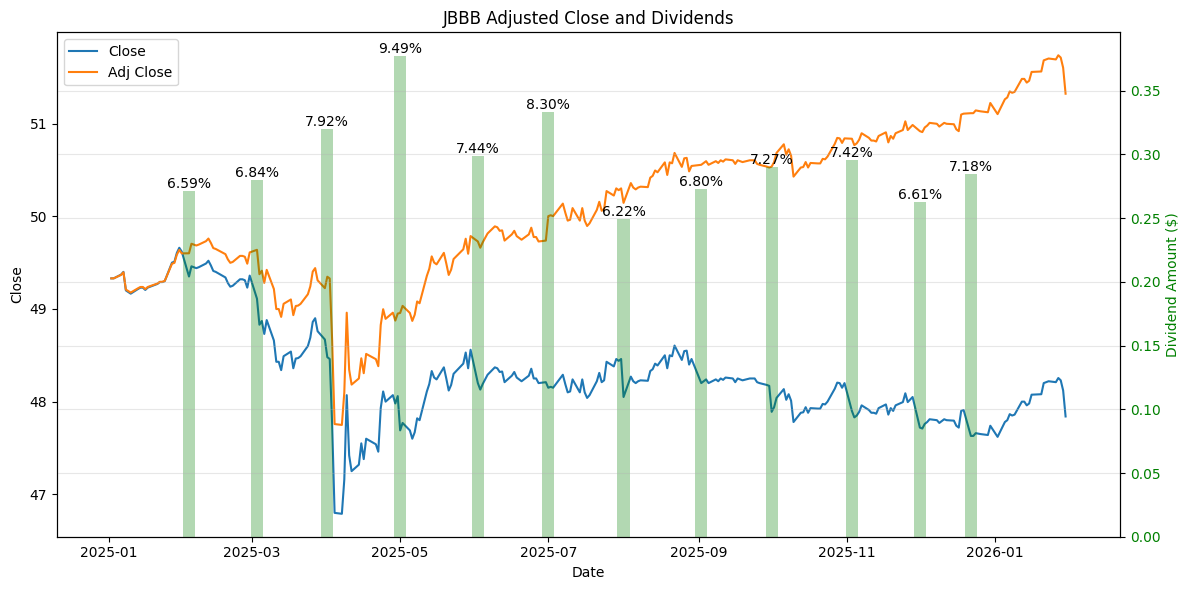

In [6]:
for ticker in ['BKLN','CLOA','PFRL','VCLT','VTC','VUSB','VWOB','AMZA', 'VYM','VYMI',"JEPI", "JEPQ","VOO","JAAA","JBBB"]:
    adj_close(ticker,start_date="2025-01-01")

In [7]:
def historical_pe_stock(ticker: str) -> pd.Series:
    t = yf.Ticker(ticker)

    # 1) Daily price history

    price = t.history(period="max", auto_adjust=False)["Close"].dropna()
    price.index = pd.to_datetime(price.index).tz_localize(None)

    # 2) Quarterly income statement (new yfinance path)
    q_inc = t.quarterly_income_stmt.copy()
    q_inc.columns = pd.to_datetime(q_inc.columns).tz_localize(None)

    if q_inc is None or q_inc.empty:
        raise ValueError(f"No quarterly income statement data available for {ticker}.")

    # yfinance usually returns columns as quarter-end dates
    q_inc = q_inc.copy()
    q_inc.columns = pd.to_datetime(q_inc.columns)

    # 3) Pull Net Income row (try common variants)
    net_income_row_candidates = [
        "Net Income",
        "Net Income Common Stockholders",
        "Net Income From Continuing Operations",
    ]
    net_income = None
    for r in net_income_row_candidates:
        if r in q_inc.index:
            net_income = q_inc.loc[r]
            break
    if net_income is None:
        raise ValueError(f"Couldn't find Net Income row in quarterly_income_stmt for {ticker}.")

    # 4) Shares: prefer diluted average shares if available (more correct historically)
    shares_row_candidates = [
        "Diluted Average Shares",
        "Diluted Shares Outstanding",
        "Basic Average Shares",
        "Basic Shares Outstanding",
    ]
    shares = None
    for r in shares_row_candidates:
        if r in q_inc.index:
            shares = q_inc.loc[r]
            break

    # Fallback: sharesOutstanding (single point-in-time; less accurate historically)
    if shares is None:
        so = t.info.get("sharesOutstanding")
        if so is None:
            raise ValueError(f"No share count found for {ticker} (no shares rows; sharesOutstanding missing).")
        shares = pd.Series(so, index=net_income.index)

    # 5) Quarterly EPS, then TTM EPS (sum last 4 quarters)
    eps_q = (net_income / shares).sort_index()
    eps_ttm = eps_q.rolling(window=4, min_periods=1).mean() * 4

    # 6) Align EPS to daily dates (forward-fill between quarter reports)
    eps_ttm_daily = eps_ttm.reindex(price.index, method="ffill")
    #eps_q_daily = eps_q.reindex(price.index, method="ffill") * 4

    pe = (price / eps_ttm_daily).dropna()
    pe.name = f"{ticker} Trailing P/E (TTM)"

    # One quarter before first available quarterly EPS date
    start_date = pd.to_datetime(eps_q.index.min()) - pd.DateOffset(months=3)

    # Slice price and P/E to start at that date
    price_plot = price.loc[start_date:]
    pe_plot = pe.loc[start_date:]

    fig, ax_pe = plt.subplots(figsize=(12, 6))

    # Left axis #1: P/E
    line_pe, = ax_pe.plot(
        pe.index,
        pe.values,
        color="tab:blue",
        linewidth=2,
        label="Trailing P/E"
    )

    ax_pe.set_ylabel("P/E Ratio", color="tab:blue")
    ax_pe.tick_params(axis="y", labelcolor="tab:blue")
    ax_pe.grid(True, alpha=0.3)

    # =========================
    # Left axis #2: Price (offset)
    # =========================
    ax_price = ax_pe.twinx()

    # Move price axis to the LEFT, slightly offset
    ax_price.spines["left"].set_position(("axes", -0.08))
    ax_price.spines["left"].set_visible(True)
    ax_price.spines["right"].set_visible(False)
    ax_price.yaxis.set_label_position("left")
    ax_price.yaxis.set_ticks_position("left")

    line_price, = ax_price.plot(
        price_plot.index,
        price_plot.values,
        color="tab:green",
        linewidth=1.8,
        label="Price"
    )

    ax_price.set_ylabel("Price", color="tab:green")
    ax_price.tick_params(axis="y", labelcolor="tab:green")

    # Right axis: Quarterly EPS (bars)
    ax_eps = ax_pe.twinx()

    bars_eps = ax_eps.bar(
        eps_q.index,
        eps_q.values,
        width=10,          # ~quarter width in days
        alpha=0.3,
        color="tab:orange",
        label="Quarterly EPS"
    )

    ax_eps.set_ylabel("Quarterly EPS", color="tab:orange")
    ax_eps.tick_params(axis="y", labelcolor="tab:orange")

    # Title & Legend
    ax_pe.set_title("Price, Trailing P/E, and Quarterly EPS Over Time")

    handles = [line_pe, line_price, bars_eps]
    labels = [h.get_label() for h in handles]
    ax_pe.legend(handles, labels, loc="upper left")

    plt.tight_layout()
    plt.show()

    return pe, eps_q

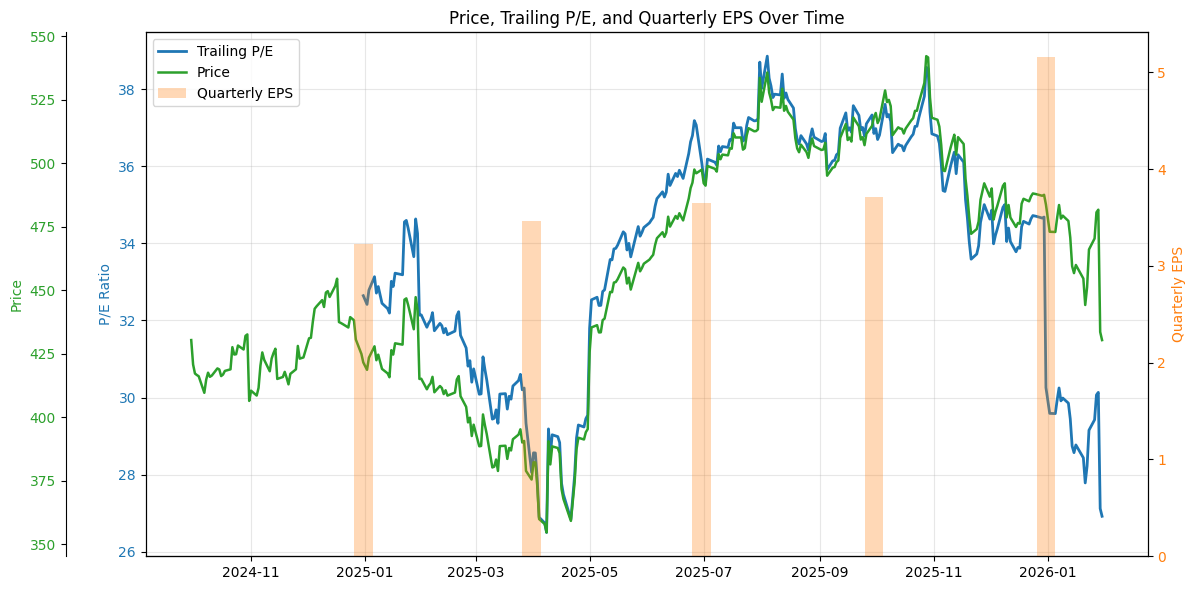

In [8]:
pe, eps_q = historical_pe_stock("MSFT")

In [9]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

def _get_quarterly_row(t, row_names):
    q = t.quarterly_income_stmt
    if q is None or q.empty:
        raise ValueError("No quarterly_income_stmt available.")
    q = q.copy()
    q.columns = pd.to_datetime(q.columns).tz_localize(None)

    for name in row_names:
        if name in q.index:
            s = q.loc[name].copy()
            s.index = pd.to_datetime(s.index).tz_localize(None)
            return s.sort_index()
    raise ValueError(f"None of these rows found: {row_names}")

def _get_quarterly_shares(t, eps_q_index):
    # Best-effort: try shares rows from the income statement; else fallback to sharesOutstanding.
    q = t.quarterly_income_stmt
    q = q.copy()
    q.columns = pd.to_datetime(q.columns).tz_localize(None)

    share_rows = [
        "Diluted Average Shares",
        "Diluted Shares Outstanding",
        "Basic Average Shares",
        "Basic Shares Outstanding",
    ]
    for r in share_rows:
        if r in q.index:
            s = q.loc[r].copy()
            s.index = pd.to_datetime(s.index).tz_localize(None)
            s = s.sort_index()
            return s.reindex(eps_q_index)  # align to your quarters

    so = t.info.get("sharesOutstanding")
    if so is None:
        raise ValueError("No shares data available (no shares rows, sharesOutstanding missing).")
    return pd.Series(so, index=eps_q_index)


def build_quarterly_metrics(ticker):
    t = yf.Ticker(ticker)

    revenue_q = _get_quarterly_row(t, ["Total Revenue", "Revenue"])
    gross_profit_q = _get_quarterly_row(t, ["Gross Profit"])
    op_income_q = _get_quarterly_row(t, ["Operating Income", "Operating Income or Loss"])

    # TTM revenue
    revenue_ttm = revenue_q.rolling(4, min_periods=1).sum()

    # Shares (best effort)
    shares_q = _get_quarterly_shares(t, revenue_q.index)

    return t, revenue_q, revenue_ttm, gross_profit_q, op_income_q, shares_q

In [10]:
def plot_pe_price_eps(pe, price, eps_q, title_prefix=""):
    # Normalize timezones
    pe = pe.copy(); pe.index = pd.to_datetime(pe.index).tz_localize(None)
    price = price.copy(); price.index = pd.to_datetime(price.index).tz_localize(None)
    eps_q = eps_q.copy(); eps_q.index = pd.to_datetime(eps_q.index).tz_localize(None)

    start_date = eps_q.index.min() - pd.DateOffset(months=3)
    pe_plot = pe.loc[start_date:]
    price_plot = price.loc[start_date:]

    fig, ax_pe = plt.subplots(figsize=(12, 6))

    # Left axis #1: P/E
    line_pe, = ax_pe.plot(pe_plot.index, pe_plot.values, label="Trailing P/E", linewidth=2)
    ax_pe.set_ylabel("P/E Ratio", color="tab:blue")
    ax_pe.tick_params(axis="y", labelcolor="tab:blue")
    ax_pe.grid(True, alpha=0.3)

    # Left axis #2: Price (offset left)
    ax_price = ax_pe.twinx()
    ax_price.spines["left"].set_position(("axes", -0.08))
    ax_price.spines["left"].set_visible(True)
    ax_price.spines["right"].set_visible(False)
    ax_price.yaxis.set_label_position("left")
    ax_price.yaxis.set_ticks_position("left")

    line_price, = ax_price.plot(price_plot.index, price_plot.values, label="Price", linewidth=1.8, color="tab:green")
    ax_price.set_ylabel("Price", color="tab:green")
    ax_price.tick_params(axis="y", labelcolor="tab:green")

    # Right axis: EPS bars
    ax_eps = ax_pe.twinx()
    bars_eps = ax_eps.bar(eps_q.index, eps_q.values, width=10, alpha=0.3, label="Quarterly EPS", color="tab:orange")
    ax_eps.set_ylabel("Quarterly EPS", color="tab:orange")
    ax_eps.tick_params(axis="y", labelcolor="tab:orange")

    ax_pe.set_title(f"{title_prefix}Price, Trailing P/E, and Quarterly EPS")

    handles = [line_pe, line_price, bars_eps]
    ax_pe.legend(handles, [h.get_label() for h in handles], loc="upper left")

    plt.tight_layout()
    plt.show()

In [11]:
def plot_ps_revenue_price(price, revenue_q, revenue_ttm, shares_q, title_prefix=""):
    price = price.copy(); price.index = pd.to_datetime(price.index).tz_localize(None)
    revenue_q = revenue_q.copy(); revenue_q.index = pd.to_datetime(revenue_q.index).tz_localize(None)
    revenue_ttm = revenue_ttm.copy(); revenue_ttm.index = pd.to_datetime(revenue_ttm.index).tz_localize(None)
    shares_q = shares_q.copy(); shares_q.index = pd.to_datetime(shares_q.index).tz_localize(None)

    # Align shares to revenue quarters and compute quarterly market cap (at quarter-end close)
    price_q = price.reindex(revenue_q.index, method="ffill")
    mktcap_q = price_q * shares_q

    ps_q = (mktcap_q / revenue_ttm).replace([np.inf, -np.inf], np.nan).dropna()

    # Start date: one quarter before first revenue
    start_date = revenue_q.index.min() - pd.DateOffset(months=3)
    price_plot = price.loc[start_date:]

    fig, ax_ps = plt.subplots(figsize=(12, 6))

    # Left axis #1: P/S (line)
    line_ps, = ax_ps.plot(ps_q.index, ps_q.values, label="P/S (TTM)", linewidth=2)
    ax_ps.set_ylabel("P/S (TTM)", color="tab:blue")
    ax_ps.grid(True, alpha=0.3)

    # Left axis #2: Price (offset left)
    ax_price = ax_ps.twinx()
    ax_price.spines["left"].set_position(("axes", -0.08))
    ax_price.spines["left"].set_visible(True)
    ax_price.spines["right"].set_visible(False)
    ax_price.yaxis.set_label_position("left")
    ax_price.yaxis.set_ticks_position("left")

    line_price, = ax_price.plot(price_plot.index, price_plot.values, label="Price", linewidth=1.8, color="tab:green")
    ax_price.set_ylabel("Price", color="tab:green")

    # Right axis: Revenue bars
    ax_rev = ax_ps.twinx()
    bars_rev = ax_rev.bar(revenue_q.index, revenue_q.values, width=10, alpha=0.3, label="Quarterly Revenue", color="tab:orange")
    ax_rev.set_ylabel("Quarterly Revenue", color="tab:orange")

    ax_ps.set_title(f"{title_prefix}Price-to-Sales (TTM) and Quarterly Revenue")

    handles = [line_ps, line_price, bars_rev]
    ax_ps.legend(handles, [h.get_label() for h in handles], loc="upper left")

    plt.tight_layout()
    plt.show()

In [12]:
def plot_margins(revenue_q, gross_profit_q, op_income_q, title_prefix=""):
    revenue_q = revenue_q.copy(); revenue_q.index = pd.to_datetime(revenue_q.index).tz_localize(None)
    gross_profit_q = gross_profit_q.copy(); gross_profit_q.index = pd.to_datetime(gross_profit_q.index).tz_localize(None)
    op_income_q = op_income_q.copy(); op_income_q.index = pd.to_datetime(op_income_q.index).tz_localize(None)

    gross_margin = (gross_profit_q / revenue_q).replace([np.inf, -np.inf], np.nan)
    op_margin = (op_income_q / revenue_q).replace([np.inf, -np.inf], np.nan)

    fig, ax = plt.subplots(figsize=(12, 6))
    line_gm, = ax.plot(gross_margin.index, gross_margin.values, label="Gross Margin", linewidth=2)
    line_om, = ax.plot(op_margin.index, op_margin.values, label="Operating Margin", linewidth=2)

    ax.set_ylabel("Margin (fraction)")
    ax.set_title(f"{title_prefix}Gross and Operating Margins (Quarterly)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

In [13]:
def plot_eps_volatility(eps_q, title_prefix=""):
    eps_q = eps_q.copy(); eps_q.index = pd.to_datetime(eps_q.index).tz_localize(None)

    eps_vol = eps_q.rolling(8, min_periods=2).std()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(eps_vol.index, eps_vol.values, label="EPS Volatility (8Q rolling std)", linewidth=2)

    ax.set_ylabel("EPS Std Dev")
    ax.set_title(f"{title_prefix}EPS Volatility (Rolling 8 Quarters)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

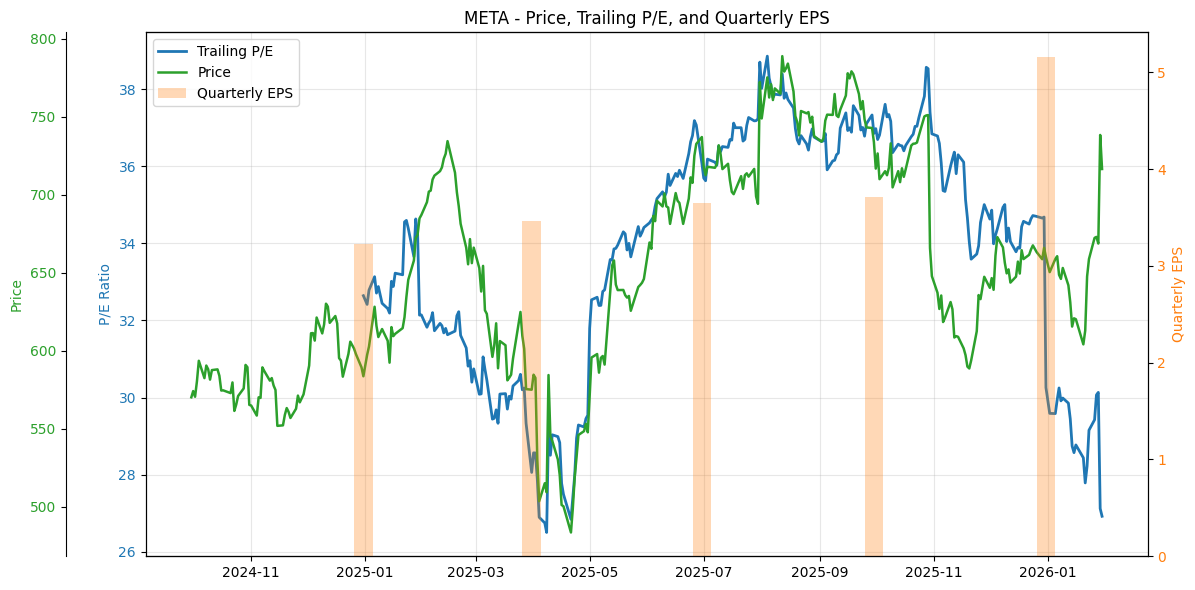

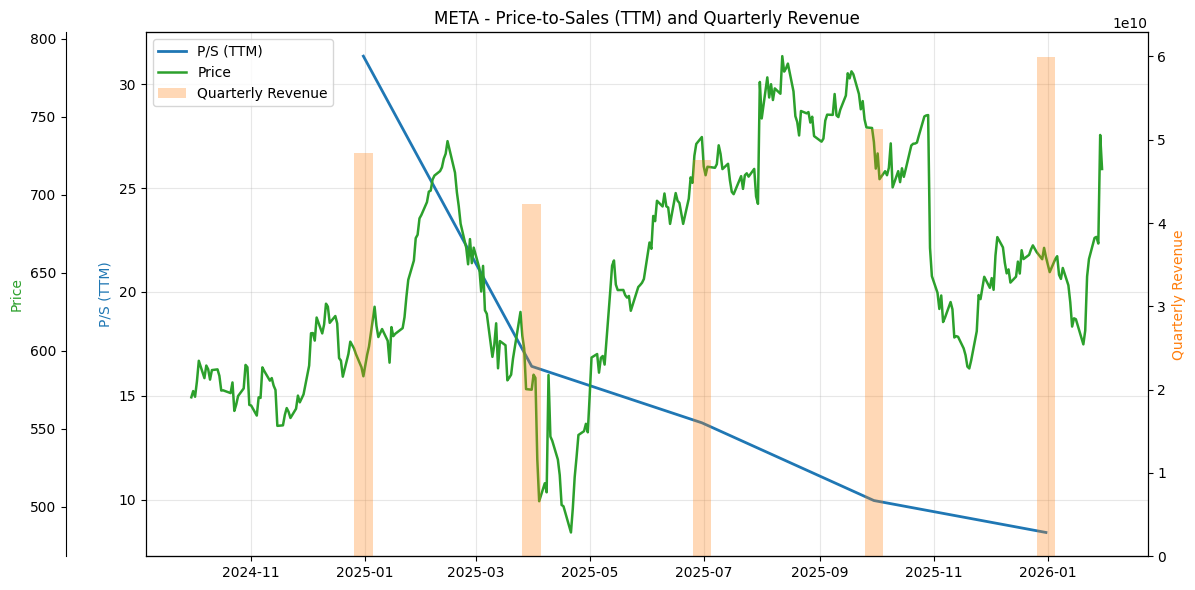

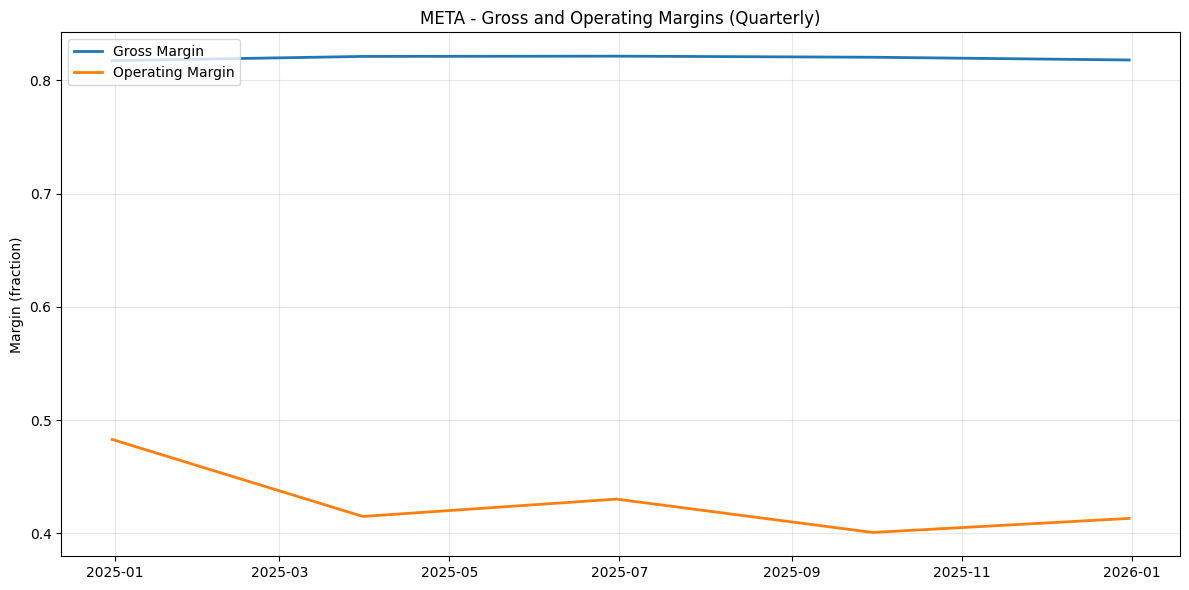

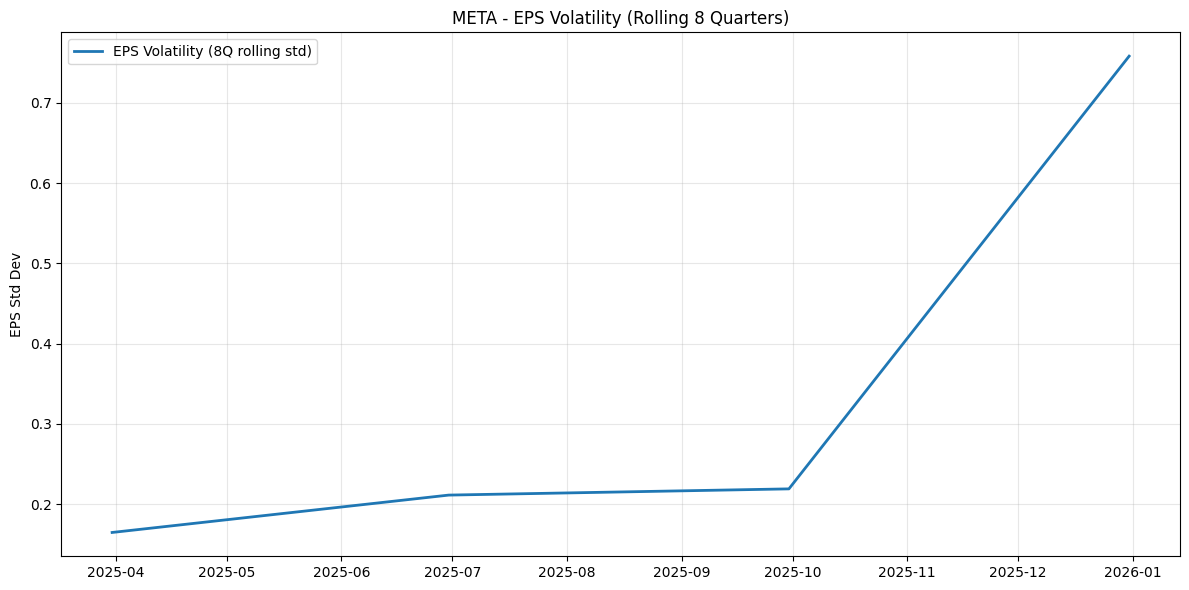

In [14]:
ticker = "META"

t, revenue_q, revenue_ttm, gross_profit_q, op_income_q, shares_q = build_quarterly_metrics(ticker)

# You already have these from your earlier code:
price = yf.Ticker(ticker).history(period="max")["Close"]
# pe = historical_pe_stock(ticker)
# eps_q = ... (your quarterly EPS series)

plot_pe_price_eps(pe, price, eps_q, title_prefix=f"{ticker} - ")
plot_ps_revenue_price(price, revenue_q, revenue_ttm, shares_q, title_prefix=f"{ticker} - ")
plot_margins(revenue_q, gross_profit_q, op_income_q, title_prefix=f"{ticker} - ")
plot_eps_volatility(eps_q, title_prefix=f"{ticker} - ")